In [17]:
import asyncio
import time
import logging
from phoenix.otel import register
from openinference.instrumentation.langchain import LangChainInstrumentor
from portfolio_optimizer import BuildGraphAvaliacaoTics, StateClassification, BuildGraphCriadorCarteira, StateCarteira
import yfinance as yf
from typing import List
import asyncio
import pandas as pd
from bcb import sgs
import pandas as pd
from sklearn.covariance import LedoitWolf
import numpy as np
from scipy.optimize import minimize
from IPython.display import display
import matplotlib.pyplot as plt
import datetime

logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

graph_tics = BuildGraphAvaliacaoTics()

graph_build = graph_tics.compile()

async def _invoke_tic(tic: str, data_inicio: str, data_fim: str):
    try:
        start = time.time()
        logger.info(f"🚀 Iniciando {tic}")
        
        result = await graph_build.ainvoke(
            StateClassification({
                "tic": tic,
                "data_inicio": data_inicio,
                "data_fim": data_fim,
                "avaliacao_analise": "",
                "description_avaliacao_analise": "",
                "interacao": 0,
            })
        )
        
        elapsed = time.time() - start
        logger.info(f"✅ {tic} concluído em {elapsed:.2f}s")
        return result
        
    except Exception as e:
        logger.error(f"❌ Erro ao processar {tic}: {e}")
        return None


async def run_all_tics(tics, data_inicio: str, data_fim: str):
    start_total = time.time()
    
    tasks = [_invoke_tic(tic, data_inicio, data_fim) for tic in tics]
    results_list = await asyncio.gather(*tasks, return_exceptions=True)
    
    elapsed_total = time.time() - start_total
    logger.info(f"⏱️  Tempo total: {elapsed_total:.2f}s")
    
    return dict(zip(tics, results_list))

def transformando_data_frame_para_markdown(results):
    try:
        results_pd = pd.DataFrame.from_dict(results).T
    except Exception as e:
        results_pd = pd.DataFrame.from_dict(results, orient="index").T
    dados_markdown = results_pd.loc[:, ["classification", "analysis"]].reset_index().rename(columns={"index": "tic"}).to_markdown()
    return dados_markdown

def correlacao(tics:List[str], data_inicio: str, data_fim: str):
    tics_yf = [tic + ".SA" for tic in tics]

    df = yf.download(tics_yf, start=data_inicio, end=data_fim, interval="1mo")["Close"]
    
    returns = df.pct_change()[4:]
    # Calcula a matriz de correlação
    correlacao = returns.corr()

    return correlacao.to_markdown()


def markowitz_opt(returns: pd.DataFrame):
    # === Estatísticas ===
    mu = returns.mean()  # retorno médio esperado
    # matriz de covariância com Ledoit–Wolf shrinkage
    lw = LedoitWolf().fit(returns)
    Sigma = lw.covariance_

    n = len(mu)

    # Retorno alvo (por exemplo, retorno médio da amostra de treino)
    target_return = mu.mean()

    # === Funções auxiliares ===
    def portfolio_performance(w, mu, Sigma):
        ret = np.dot(w, mu)
        vol = np.sqrt(np.dot(w.T, np.dot(Sigma, w)))
        return ret, vol

    def objective(w, mu, Sigma, target):
        ret, vol = portfolio_performance(w, mu, Sigma)
        return vol  # minimiza a volatilidade

    # === Restrições ===
    constraints = (
        {'type': 'eq', 'fun': lambda w: np.sum(w) - 1},              # soma = 1
        {'type': 'eq', 'fun': lambda w: np.dot(w, mu) - target_return},  # retorno alvo
    )
    bounds = tuple((0, 1) for _ in range(n))  # sem short

    # === Otimização ===
    w0 = np.repeat(1/n, n)
    opt = minimize(
        objective, w0, args=(mu, Sigma, target_return),
        method='SLSQP', bounds=bounds, constraints=constraints
    )

    weights = opt.x

    # === Aplicação dos pesos ao conjunto de retornos ===
    markowitz_cr = (1 + (weights * returns).sum(axis=1)).cumprod()

    weights_markowitz = pd.DataFrame(
        np.tile(weights, (len(returns), 1)),  # repete o vetor em todas as linhas
        index=returns.index,
        columns=returns.columns
    )

    return weights_markowitz, markowitz_cr

def get_selic_multiplos_periodos(data_inicio, data_fim, anos_por_janela=5):
    """
    Busca dados da SELIC em janelas de X anos para contornar limitação da API
    """
    inicio = pd.to_datetime(data_inicio)
    fim = pd.to_datetime(data_fim)
    
    # Lista para armazenar os dataframes
    dados_completos = []
    
    # Criar janelas
    current_start = inicio
    
    while current_start < fim:
        current_end = min(current_start + pd.DateOffset(years=anos_por_janela), fim)
        
        print(f"Buscando dados de {current_start.date()} até {current_end.date()}...")
        
        try:
            # Fazer requisição para a janela atual
            dados_janela = sgs.get({'selic': 11, 
                                    #'cdi' :12
                                    }, 
                                   start=current_start.strftime('%Y-%m-%d'),
                                   end=current_end.strftime('%Y-%m-%d'))
            
            dados_completos.append(dados_janela)
            print(f"  ✓ {len(dados_janela)} registros obtidos")
            
        except Exception as e:
            print(f"  ✗ Erro ao buscar dados: {e}")

        current_start = current_end + pd.Timedelta(days=1)

    if dados_completos:
        selic_completo = pd.concat(dados_completos)
        selic_completo = selic_completo[~selic_completo.index.duplicated(keep='first')]
        selic_completo = selic_completo.sort_index()
        
        print(f"\n✓ Total de registros: {len(selic_completo)}")
        print(f"✓ Período: {selic_completo.index.min().date()} até {selic_completo.index.max().date()}")
        
        return selic_completo
    else:
        print("Nenhum dado foi obtido!")
        return None
    
def daily_returns(prices):
    return prices.pct_change()[1:]

def daily_returns_carteira(prices, pesos):
    pesos_porcentagem = pesos_porcentagem = [peso/100 for peso in pesos]
    variacao_diaria_carteira = (prices.pct_change()[1:] * (pesos_porcentagem)).sum(axis=1)
    return variacao_diaria_carteira

def annualized_volatility(daily_ret, trading_days=252):
    return daily_ret.std() * np.sqrt(trading_days)

def annualized_mean_return(daily_ret, trading_days=252):
    return daily_ret.mean() * trading_days

def cagr(prices):
    days = (prices.index[-1] - prices.index[0]).days
    years = days / 365.25
    return (prices.iloc[-1] / prices.iloc[0])**(1/years) - 1 if years > 0 else np.nan

def max_drawdown(prices):
    cum_max = prices.cummax()
    drawdowns = (prices - cum_max) / cum_max
    return drawdowns.min()

def avg_drawdown(prices):
    dd = (prices / prices.cummax()) - 1
    negatives = dd < 0
    groups = (negatives.astype(int).diff() != 0).cumsum()
    avg_dds = []
    for _, grp in dd.groupby(groups):
        if (grp < 0).any():
            avg_dds.append(grp.min())
    return np.mean(avg_dds) if avg_dds else 0.0

def calmar_ratio(prices):
    ann_ret = cagr(prices)
    mdd = max_drawdown(prices)
    return ann_ret / abs(mdd) if mdd != 0 else np.nan

def sortino_ratio(daily_ret, required_return=0.0, trading_days=252):
    rr_daily = (1 + required_return)**(1/trading_days) - 1
    downside = daily_ret[daily_ret < rr_daily] - rr_daily
    if downside.size == 0:
        return np.nan
    dd = np.sqrt((downside**2).mean()) * np.sqrt(trading_days)
    ann_ret = annualized_mean_return(daily_ret, trading_days)
    return (ann_ret - required_return) / dd if dd != 0 else np.nan

def compute_metrics(price_df):
    metrics = {}
    for col in price_df.columns:
        p = price_df[col].dropna()
        #dr = daily_returns_carteira(p, pesos)
        metrics[col] = {
            "ann_vol": annualized_volatility(p),
            "ann_mean_ret": annualized_mean_return(p),
            "cagr": cagr(p),
            "max_drawdown": max_drawdown(p),
            "avg_drawdown": avg_drawdown(p),
            "calmar": calmar_ratio(p),
            "sortino": sortino_ratio(p)
        }
    return pd.DataFrame(metrics).T


def normalizar_pesos(weights_dict, target_sum=100, tolerancia=0.01):
    """
    Normaliza os pesos para somarem exatamente o target_sum.
    
    Args:
        weights_dict: Dicionário com os pesos {ticker: peso}
        target_sum: Soma alvo (padrão: 100)
        tolerancia: Tolerância para considerar soma correta (padrão: 0.01)
    
    Returns:
        Dicionário com pesos normalizados
    """
    total_atual = sum(weights_dict.values())
    diferenca = abs(total_atual - target_sum)
    
    # Se já está dentro da tolerância, retorna o original
    if diferenca <= tolerancia:
        logger.info(f"✓ Pesos já somam {total_atual:.2f}% (dentro da tolerância)")
        return weights_dict
    
    # Normalização proporcional (melhor que distribuir igualmente)
    fator_normalizacao = target_sum / total_atual
    weights_normalizados = {
        ticker: peso * fator_normalizacao 
        for ticker, peso in weights_dict.items()
    }
    
    # Log da correção
    logger.warning(
        f"⚠ Pesos ajustados: {total_atual:.2f}% → {target_sum:.2f}% "
        f"(fator: {fator_normalizacao:.4f})"
    )
    
    # Verificação final
    soma_final = sum(weights_normalizados.values())
    logger.info(f"✓ Soma final: {soma_final:.4f}%")
    
    return weights_normalizados

class ComputandoMetricas:
    def __init__(self, 
                 data_inicio, 
                 data_fim, 
                 carteira,
                 valor_investido=1000):
        self.data_inicio = data_inicio
        self.data_fim = data_fim
        self.carteira = carteira
        self.valor_investido = valor_investido
        self.ibov, self.df = self.carregando_dados()
        self.tics_selecionados, self.pesos_carteira = self.ajustando_pesos_carteira()
    
        
    def carregando_dados(self):
        tics_selecionados = [tic if tic.endswith(".SA") else f"{tic}.SA" for tic in self.carteira.keys()]
        ibov = yf.download("^BVSP", start=self.data_inicio, end=self.data_fim)["Close"]
        df = yf.download(tics_selecionados, start=self.data_inicio, end=self.data_fim)["Close"]
        df.dropna(axis=1, how='all', inplace=True)
        return ibov, df
    
    def cumulative_returns(self):
        return (self.df.apply(daily_returns)+1).cumprod()
    
    def ajustando_pesos_carteira(self):
        dict_carteiras = self.carteira.copy()
        tic_validos = list(self.df.columns)
        carteira_valida = {key: value for key, value in dict_carteiras.items() if key + ".SA" in tic_validos}
        carteira_valida = {
            key: value for key, value in dict_carteiras.items()
            if (key.endswith(".SA") and key in tic_validos) or 
            (not key.endswith(".SA") and key + ".SA" in tic_validos)
        } 
        carteira_pesos_acoes_validos = normalizar_pesos(carteira_valida)
        tics_selecionados = list(carteira_pesos_acoes_validos.keys())
        pesos = list(carteira_pesos_acoes_validos.values()) 
        return tics_selecionados, pesos
        
    def computando_marcowitz(self):
        weights_markowitz, markowitz_cr = markowitz_opt(self.df.pct_change().dropna())
        return weights_markowitz, markowitz_cr
        
    def daily_returns_carteira_markowitz(self):
        weights_markowitz, markowitz_cr = self.computando_marcowitz()
        pesos_markowitz = [peso*100 for peso in weights_markowitz.iloc[-1].to_list()]
        retornos_carteira_markowitz = daily_returns_carteira(self.df, pesos_markowitz)
        return retornos_carteira_markowitz
    
    def retornos_diarios_carteira(self):
        retornos_diarios_carteira = daily_returns_carteira(self.df, self.pesos_carteira)
        return retornos_diarios_carteira
    
    def retornos_diarios_ibov(self):
        retorno_diario = self.ibov.pct_change()[1:]
        return retorno_diario
    
    def data_frame_comparacao_retorno_diario(self):
        retornos_carteira = self.retornos_diarios_carteira()
        retornos_ibov = self.retornos_diarios_ibov()
        retornos_markowitz = self.daily_returns_carteira_markowitz()
        comparacao_carteira = pd.concat([retornos_carteira, 
                                 retornos_ibov, 
                                 retornos_markowitz], axis=1,).rename(columns={0: "Carteira", 
                                                                               "^BVSP": "IBOV", 
                                                                               1: "Markowitz"})
        return comparacao_carteira
    
    def metrica_comparacao_carteira_ibov_retornos_markowitz(self):
        comparacao_carteira = self.data_frame_comparacao_retorno_diario()
        comp_metrics = compute_metrics(comparacao_carteira)
        return comp_metrics
    
    def retorno_menetario_ibov(self):
        ibov_retornos = (self.ibov.pct_change()[1:]+1).cumprod() *self.valor_investido
        return ibov_retornos
    
    def retorno_carteira_monetario(self):
        pesos_frac = [p/100 for p in self.pesos_carteira]
        valor_investido_carteira = [self.valor_investido * peso for peso in pesos_frac]
        retorno_carteira = (self.cumulative_returns() * valor_investido_carteira).sum(axis=1)
        return retorno_carteira
    
    def data_frame_comparacao_retorno_monetario(self):
        ibov_retornos = self.retorno_menetario_ibov()
        retorno_carteira = self.retorno_carteira_monetario()
        _ , markowitz_cr = self.computando_marcowitz()
        selic = self.retorno_selic()

        retorno_acumulado_monetario = pd.concat([ibov_retornos, retorno_carteira, markowitz_cr*self.valor_investido, selic], axis=1).rename(columns={"^BVSP": "IBOV", 0: "Carteira", 1: "Markowitz", "selic":"Selic"})
        return retorno_acumulado_monetario
    
    def retorno_selic(self):
        selic = get_selic_multiplos_periodos(self.data_inicio, self.data_fim)
        selic_acumulada =  ((selic/100 + 1).cumprod())*self.valor_investido
        return selic_acumulada
    
    def print_results(self, save_path="../data/"):
        import os
        from datetime import datetime
        
        # Criar diretório se não existir
        os.makedirs(save_path, exist_ok=True)
    
        
        metrics = self.metrica_comparacao_carteira_ibov_retornos_markowitz()
        retorno_acumulado_monetario = self.data_frame_comparacao_retorno_monetario()
        
        print("\n" + "="*40)
        print("📊 Métricas de Comparação das Carteiras")
        print("="*40)
        
        # Salvar métricas em CSV
        metrics_file = os.path.join(save_path, "metricas.csv")
        metrics.to_csv(metrics_file)
        print(f"✅ Métricas salvas em: {metrics_file}")
    
        display(metrics.style.set_caption("Métricas das Carteiras").background_gradient(cmap="Blues"))
    
        plt.figure(figsize=(10, 6))
        cores = {'IBOV': '#1f77b4', 'Carteira': '#2ca02c', 'Markowitz': '#d62728', 'Selic': "#d66427"}

        for nome in ['IBOV', 'Carteira', 'Markowitz', 'Selic']:
            plt.plot(
                retorno_acumulado_monetario.index,
                retorno_acumulado_monetario[nome],
                label=nome,
                color=cores[nome]
            )
            ultimo_x = retorno_acumulado_monetario.index[-2]
            ultimo_y = retorno_acumulado_monetario[nome].iloc[-2]
            plt.text(
                ultimo_x, ultimo_y,
                f'R$ {ultimo_y:,.2f}',
                color=cores[nome],
                fontsize=11,
                va='center',
                fontweight='bold'
            )

        plt.legend()
        plt.xlabel("Data")
        plt.ylabel("Retorno Monetário da Carteira")
        plt.title(f"Retorno Monetário da Carteira vs Ibov vs Markowitz (Valor inicial de R$ {self.valor_investido})")
        
        # Salvar gráfico
        grafico_file = os.path.join(save_path, f"grafico_retornos.png")
        plt.savefig(grafico_file, dpi=300, bbox_inches='tight')
        print(f"✅ Gráfico salvo em: {grafico_file}")
        
        plt.show()
        
        # Salvar retornos acumulados em CSV
        retornos_file = os.path.join(save_path, f"retornos_acumulados.csv")
        retorno_acumulado_monetario.to_csv(retornos_file)
        print(f"✅ Retornos acumulados salvos em: {retornos_file}")
        
        print("\n" + "="*40)
        
        return retorno_acumulado_monetario
    

def sequencia_datas(start, end, freq="QS"):
    data_hoje = datetime.datetime.now().strftime("%Y-%m-%d")
    periodo_datas = pd.date_range(start=start, end=data_hoje, freq=freq)
    
    datas_dict = {}
    
    for data in periodo_datas:
        novos_trimestres = pd.date_range(start=data, periods=8, freq='Q')
        data_inicio = novos_trimestres[0].strftime("%Y-%m-%d")
        data_fim = novos_trimestres[-1].strftime("%Y-%m-%d")
        
        if data_fim > data_hoje:
            data_fim = data_hoje
            datas_dict[data_inicio] = data_fim
            return datas_dict
        
        datas_dict[data_inicio] = data_fim
        
    
    return datas_dict
    

def selecionar_tics_bom_excelente(dict_tics):
    classificacao_boa = [
   "good", "excellent",
    ]
    response = {}
    for k, v in dict_tics.items():
        try:
            if v is not None and v.get('classification').lower() in classificacao_boa:
                response[k] = v
        except Exception as e:
            continue
            logger.error(f"Erro ao processar {k}: {e}")
    
    return response
    

c:\Users\jefer\Documents\Ciencia-de-dados\LLMs\Agent-Portfolio-Optimizer\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
INFO:phoenix.config:📋 Ensuring phoenix working directory: C:\Users\jefer\.phoenix
INFO:phoenix.inferences.inferences:Dataset: phoenix_inferences_5c99b83e-4379-4c1b-8c08-49715cfd752f initialized


In [18]:

import json
with open("../data/pesos_carteira_historico.json", "r") as f:
    results_dict = json.load(f)

In [ ]:
results_dict

{'2023-03-31_to_2024-12-31': {'tickers_weights': {'ABEV3.SA': 4.545454545454545,
   'WEGE3.SA': 13.636363636363637,
   'CAMB3.SA': 13.636363636363637,
   'BRAP3.SA': 4.545454545454545,
   'CGAS5.SA': 9.09090909090909,
   'CMIG4.SA': 9.09090909090909,
   'ENEV3.SA': 9.09090909090909,
   'FIQE3.SA': 4.545454545454545,
   'FLRY3.SA': 6.818181818181818,
   'HYPE3.SA': 9.09090909090909,
   'ITSA3.SA': 9.09090909090909,
   'VIVT3.SA': 6.818181818181818},
  'justification': 'Prioritized assets with Excellent classifications (WEGE3, CAMB3) for higher returns and lower risk, limited allocations to assets with higher correlations like ITSA3 and VIVT3 to maintain diversification. Weights adjusted to meet minimum 5% constraint, with total concentrations under 20%. Poor assets excluded completely, ensuring compliance with constraints.',
  'analise_avaliador_weights': 'Okay, let\'s tackle this evaluation step by step. First, I need to check all the constraints to ensure compliance.\n\nStarting with 

: 

In [ ]:
import os
import json
import logging

logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

diretorio = '../data/avaliacao_historicos_tics'

arquivos = os.listdir(diretorio)

avaliacoes_historicas = {}

for arquivo in arquivos:
    name_arquivo = arquivo.split(".")[0].split("avaliacao_tics_historico_")[1]
    try:
        with open(os.path.join(diretorio, arquivo), 'r') as f:
            avaliacoes_historicas[name_arquivo] = json.load(f)
    except:
        logger.error(f"Erro ao carregar o arquivo {arquivo}")
        pass
    

In [109]:
results_dict

{'2023-03-31_to_2024-12-31': {'tickers_weights': {'CAMB3.SA': 9.09090909090909,
   'WEGE3.SA': 18.18181818181818,
   'FLRY3.SA': 13.636363636363637,
   'EGIE3.SA': 10.909090909090908,
   'ENEV3.SA': 9.09090909090909,
   'CSMG3.SA': 7.2727272727272725,
   'CGAS3.SA': 4.545454545454545,
   'ITSA3.SA': 6.363636363636363,
   'FIQE3.SA': 5.454545454545454,
   'VIVT3.SA': 6.363636363636363,
   'WIZC3.SA': 4.545454545454545,
   'HYPE3.SA': 4.545454545454545},
  'justification': "The portfolio prioritizes 'Excellent' assets (CAMB3 at 10%, WEGE3 at 20%) for higher quality. The remaining assets are selected for low correlation clusters (e.g., CGAS3 and CSMG3). WEGE3's strong fundamentals and CAMB3's low leverage reduce risk. Diversified sectors and low individual weights (none over 20%) minimize concentration. The weighted average correlation is estimated at 0.3 via sector spreads and correlations like 0.2 with WEGE3. The total Poor/PPP exposure is 0% as all assets are Good/Excellent.",
  'anali

# Criando pesos marcowitz

In [53]:
import yfinance as yf
import logging
import pandas as pd
import datetime
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

In [67]:
pesos_carteira_marcowitz = {}

for key, value in results_dict.items(): 
    
    acoes = list(value['tickers_weights'].keys())
    
    acoes_sa = [acao if acao.endswith(".SA") else f"{acao}.SA"  for acao in acoes]
    
    data_split = key.split("_to_")
    
    start = data_split[0]
    
    end = data_split[1]
    try:
    
        comp = ComputandoMetricas(str(start), str(end), value['tickers_weights'],1000)
            
        weights_markowitz, _ = comp.computando_marcowitz()
            
        computando_marcowitz = weights_markowitz.iloc[-1].to_dict()
            
        pesos_carteira_marcowitz[f"{start}_to_{end}"] = computando_marcowitz
    except Exception as e:
        logger.error(f"Erro ao computar Markowitz para o período {start} a {end}: {e}")
        continue

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  4 of 4 completed
INFO:__main__:✓ Pesos já somam 100.00% (dentro da tolerância)
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  3 of 3 completed
INFO:__main__:✓ Pesos já somam 100.00% (dentro da tolerância)
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
INFO:__main__:✓ Pesos já somam 100.00% (dentro da tolerância)
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
INFO:__main__:✓ Pesos já somam 100.00% (dentro da tolerância)
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  5 of 5 completed
INFO:__main__:✓ Pesos já somam 100.00% (dentro da tolerância)


In [68]:
pesos_carteira_marcowitz

{'2023-03-31_to_2024-12-31': {'GGBR4.SA': 0.31724262968587547,
  'LREN3.SA': 0.019616721392271615,
  'PETR4.SA': 0.17549557572768434,
  'VIVT3.SA': 0.4876450731941686},
 '2023-06-30_to_2025-03-31': {'ITUB4.SA': 0.23973653264844683,
  'LREN3.SA': 0.31676295257733933,
  'VIVT3.SA': 0.44350051477421387},
 '2023-09-30_to_2025-06-30': {'ABEV3.SA': 1.0},
 '2023-12-31_to_2025-09-30': {'VIVT3.SA': 1.0},
 '2024-03-31_to_2025-12-29': {'ITUB4.SA': 0.2013462028945901,
  'LREN3.SA': 0.0,
  'PETR4.SA': 0.39826276285263973,
  'PSSA3.SA': 0.18310191392354042,
  'VIVT3.SA': 0.2172891203292298}}

# Coletando dados dos proximos trimestres dos tickers selecionados

In [72]:

precos_carteira = {}

for key, value in results_dict.items():
    
    acoes = list(value['tickers_weights'].keys())
    
    acoes_sa = [acao if acao.endswith(".SA") else f"{acao}.SA"  for acao in acoes]
    
    data_split = key.split("_to_")

    start = data_split[1]
    
    data = pd.Timestamp(start)
    
    end = data + pd.DateOffset(months=3)
    
    end = end.strftime("%Y-%m-%d")
    
    date_now = datetime.datetime.now().strftime("%Y-%m-%d")
    
    if end > date_now:
        logger.info("Data final da carteira maior que a data atual, ajustando para a data atual.")
        end = date_now

        
    logger.info(f"Baixando dados de {start} a {end}, para as acoes {acoes_sa}")
    
    precos_carteira[f"{start}"] = yf.download(acoes_sa, start=str(start), end= str(end))["Close"]
    
    pesos = list(value['tickers_weights'].values())
    
    


precos_carteira_marcowitz = {}

for key, value in pesos_carteira_marcowitz.items():
    acoes = list(value.keys())
    acoes_sa = [acao if acao.endswith(".SA") else f"{acao}.SA"  for acao in acoes]
    
    data_split = key.split("_to_")

    start = data_split[1]
    
    data = pd.Timestamp(start)
    
    end = data + pd.DateOffset(months=3)
    
    end = end.strftime("%Y-%m-%d")
    
    date_now = datetime.datetime.now().strftime("%Y-%m-%d")
    
    if end > date_now:
        logger.info("Data final da carteira maior que a data atual, ajustando para a data atual.")
        end = date_now
    logger.info(f"Baixando dados de {start} a {end}, para as acoes {acoes_sa}")
    precos_carteira_marcowitz[f'{start}'] = yf.download(acoes_sa, start=str(start), end= str(end))["Close"]

INFO:__main__:Baixando dados de 2024-12-31 a 2025-03-31, para as acoes ['PETR4.SA', 'GGBR4.SA', 'LREN3.SA', 'VIVT3.SA']
[*********************100%***********************]  4 of 4 completed
INFO:__main__:Baixando dados de 2025-03-31 a 2025-06-30, para as acoes ['ITUB4.SA', 'LREN3.SA', 'VIVT3.SA']
[*********************100%***********************]  3 of 3 completed
INFO:__main__:Baixando dados de 2025-06-30 a 2025-09-30, para as acoes ['ABEV3.SA']
[*********************100%***********************]  1 of 1 completed
INFO:__main__:Baixando dados de 2025-09-30 a 2025-12-30, para as acoes ['VIVT3.SA']
[*********************100%***********************]  1 of 1 completed
INFO:__main__:Data final da carteira maior que a data atual, ajustando para a data atual.
INFO:__main__:Baixando dados de 2025-12-29 a 2025-12-31, para as acoes ['PETR4.SA', 'ITUB4.SA', 'LREN3.SA', 'PSSA3.SA', 'VIVT3.SA']
[*********************100%***********************]  5 of 5 completed
INFO:__main__:Baixando dados de 2024-

In [73]:
pesos_carteira_marcowitz

{'2023-03-31_to_2024-12-31': {'GGBR4.SA': 0.31724262968587547,
  'LREN3.SA': 0.019616721392271615,
  'PETR4.SA': 0.17549557572768434,
  'VIVT3.SA': 0.4876450731941686},
 '2023-06-30_to_2025-03-31': {'ITUB4.SA': 0.23973653264844683,
  'LREN3.SA': 0.31676295257733933,
  'VIVT3.SA': 0.44350051477421387},
 '2023-09-30_to_2025-06-30': {'ABEV3.SA': 1.0},
 '2023-12-31_to_2025-09-30': {'VIVT3.SA': 1.0},
 '2024-03-31_to_2025-12-29': {'ITUB4.SA': 0.2013462028945901,
  'LREN3.SA': 0.0,
  'PETR4.SA': 0.39826276285263973,
  'PSSA3.SA': 0.18310191392354042,
  'VIVT3.SA': 0.2172891203292298}}

In [74]:
precos_carteira_marcowitz

{'2024-12-31': Ticker       GGBR4.SA   LREN3.SA   PETR4.SA   VIVT3.SA
 Date                                                  
 2025-01-02  17.272533  11.347687  33.027279  22.255062
 2025-01-03  16.703533  11.489532  32.676979  22.160484
 2025-01-06  17.388264  11.848875  32.524281  22.576637
 2025-01-07  17.301466  12.359522  33.215904  23.040092
 2025-01-08  16.973570  12.170395  32.946442  22.344917
 2025-01-09  16.491364  12.293326  33.090153  22.666496
 2025-01-10  16.202042  12.142025  33.179977  22.165213
 2025-01-13  16.385279  12.151482  33.296741  22.151024
 2025-01-14  16.462433  11.924527  33.072193  22.311815
 2025-01-15  17.021786  12.482455  33.494350  23.096840
 2025-01-16  16.645670  11.735398  33.278778  22.936054
 2025-01-17  16.751755  11.659748  33.413517  23.219795
 2025-01-20  16.906057  11.725943  33.494350  23.191423
 2025-01-21  17.272533  11.839420  33.503334  23.560291
 2025-01-22  16.973570  12.416262  33.314709  23.929161
 2025-01-23  16.838549  12.293326 

In [75]:
def daily_returns(prices):
    return prices.pct_change()[1:]

def cumulative_returns(df):
    return (df.apply(daily_returns)+1).cumprod()

def retorno_carteira_monetario(df, pesos, valor_investido):
    pesos_frac = [p/100 for p in pesos]
    valor_investido_carteira = [valor_investido * peso for peso in pesos_frac]
    retorno_carteira = (cumulative_returns(df) * valor_investido_carteira).sum(axis=1)
    return retorno_carteira

def retorno_percentual_acao_individual(pesos_carteiras, precos_carteira):
    """pesos_frac = [p/100 for p in pesos_carteiras[chaves[keys]].values()]
    valor_investido_carteira = [1000 * peso for peso in pesos_frac]
    retorno_carteira = (cumulative_returns(precos_carteira[chaves[keys]]) * valor_investido_carteira)"""
    
    
    pesos_frac = [p/100 for p in pesos_carteiras.values()]
    valor_investido_carteira = [1000 * peso for peso in pesos_frac]
    
    # Usar diretamente precos_df (já é o DataFrame correto)
    retorno_carteira = cumulative_returns(precos_carteira) * valor_investido_carteira
    
    retorno_percentual = retorno_carteira.apply(
        lambda x: (x.iloc[-1] - x.iloc[0]) / x.iloc[0] * 100
    )
    return retorno_percentual

In [76]:
precos_carteira

{'2024-12-31': Ticker       GGBR4.SA   LREN3.SA   PETR4.SA   VIVT3.SA
 Date                                                  
 2025-01-02  17.272533  11.347687  33.027279  22.255062
 2025-01-03  16.703533  11.489532  32.676979  22.160484
 2025-01-06  17.388264  11.848875  32.524281  22.576637
 2025-01-07  17.301466  12.359522  33.215904  23.040092
 2025-01-08  16.973570  12.170395  32.946442  22.344917
 2025-01-09  16.491364  12.293326  33.090153  22.666496
 2025-01-10  16.202042  12.142025  33.179977  22.165213
 2025-01-13  16.385279  12.151482  33.296741  22.151024
 2025-01-14  16.462433  11.924527  33.072193  22.311815
 2025-01-15  17.021786  12.482455  33.494350  23.096840
 2025-01-16  16.645670  11.735398  33.278778  22.936054
 2025-01-17  16.751755  11.659748  33.413517  23.219795
 2025-01-20  16.906057  11.725943  33.494350  23.191423
 2025-01-21  17.272533  11.839420  33.503334  23.560291
 2025-01-22  16.973570  12.416262  33.314709  23.929161
 2025-01-23  16.838549  12.293326 

In [77]:
def verificando_valores_nulos(pesos_carteiras, precos_carteira):
    #dict_keys = pesos_carteiras[values]['tickers_weights'].copy()
    null = precos_carteira.isna().any()
    list_name_null = precos_carteira.loc[:,null].columns.to_list()
    
    dict_keys = {
        (key if key.endswith(".SA") else f"{key}.SA"): value 
        for key, value in pesos_carteiras.items()
    }
    valor_do_tic_null = 0
    for tic in list_name_null:
        valor_do_tic_null += dict_keys[tic]
        dict_keys.pop(tic)  
    
    quantidade_sobrou = len(dict_keys)
    
    if quantidade_sobrou == 0:
        return {}  # Evitar divisão por zero
    
    valor_para_cada_tic = valor_do_tic_null / quantidade_sobrou
    
    dict_com_novos_valores = {}
    for key, value in dict_keys.items():
        dict_com_novos_valores[key] = value + valor_para_cada_tic
    
    return dict_com_novos_valores

In [101]:
from IPython.display import display, Markdown
import pandas as pd
carteira = pd.DataFrame()
carteira_marcowitz = pd.DataFrame()

interacoes = 0

for key, value in results_dict.items():
    data_split = key.split("_to_")
    start = data_split[0]
    end = data_split[1]
    print("*" * 40)
    display(Markdown(f"**O retorno da carteira para o período: {key}**"))
    
    pesos_carteira = value['tickers_weights']
    
    precos_carteira_selecionada = precos_carteira[end]
    
    pesos_sem_erro = verificando_valores_nulos(pesos_carteira, precos_carteira_selecionada)
    
    precos_sem_nan = precos_carteira[end].dropna(axis=1)
    
    carteira_percentual_acoes = retorno_percentual_acao_individual(pesos_sem_erro, precos_sem_nan)
    
    try:
        pesos_carteira_marcowitz_selecionada = pesos_carteira_marcowitz[key]
        precos_carteira_marcowitz_selecionada = precos_carteira_marcowitz[end]
        pesos_sem_erro_markowitz = verificando_valores_nulos(pesos_carteira_marcowitz_selecionada, precos_carteira_marcowitz_selecionada)
        pesos_sem_erro_markowitz = {key_: value*100 for key_, value in pesos_sem_erro_markowitz.items()}
    
        precos_sem_nan_markwitz = precos_carteira_marcowitz[end].dropna(axis=1)
    
        carteira_percentual_acoes_marcowitz = retorno_percentual_acao_individual(pesos_sem_erro_markowitz, precos_sem_nan_markwitz)
    except Exception as e:  
        logger.info(f"Erro ao obter:{e}")
    
    data = pd.DataFrame(pesos_sem_erro, index=["Pesos"]).T
    data_markwitz = pd.DataFrame(pesos_sem_erro_markowitz, index=["Pesos"]).T
    
    if not carteira_percentual_acoes.empty:
        data['retornos em %'] = pd.DataFrame(carteira_percentual_acoes)
        data_markwitz['retornos markwitz em %'] = pd.DataFrame(carteira_percentual_acoes_marcowitz)
    else:
        print("Nenhum dado foi obtido!")
        
    display(data.T.style.set_caption("Pesos").background_gradient(cmap="Blues"))
    
    display(data_markwitz.T.style.set_caption("Pesos").background_gradient(cmap="Blues"))
    
    if interacoes == 0:
        valor_carteira = retorno_carteira_monetario(precos_sem_nan, pesos_sem_erro.values(), 1000)
        
        valor_carteira_markwitz = retorno_carteira_monetario(precos_sem_nan_markwitz, pesos_sem_erro_markowitz.values(), 1000)

        
    else:   
        valor_carteira = retorno_carteira_monetario(precos_sem_nan, pesos_sem_erro.values(), valor_atual_carteira)
        
        valor_carteira_markwitz = retorno_carteira_monetario(precos_sem_nan_markwitz, pesos_sem_erro_markowitz.values(), valor_atual_carteira_markwitz)
    
    carteira = pd.concat([carteira, valor_carteira])
    carteira_marcowitz = pd.concat([carteira_marcowitz, valor_carteira_markwitz])
    
    try:
        valor_atual_carteira = int(valor_carteira.iloc[-1])
        valor_atual_carteira_markwitz = int(valor_carteira_markwitz.iloc[-1])
    
    except:
        pass
    
    interacoes = interacoes + 1
    

****************************************


**O retorno da carteira para o período: 2023-03-31_to_2024-12-31**

,PETR4.SA,GGBR4.SA,LREN3.SA,VIVT3.SA
Pesos,26.315789,21.052632,26.315789,26.315789
retornos em %,2.886200,-1.835715,4.763561,10.219068


,GGBR4.SA,LREN3.SA,PETR4.SA,VIVT3.SA
Pesos,31.724263,1.961672,17.549558,48.764507
retornos markwitz em %,-1.835715,4.763561,2.886200,10.219068


****************************************


...

,VIVT3.SA
Pesos,100.000000
retornos markwitz em %,-2.179756


****************************************


**O retorno da carteira para o período: 2024-03-31_to_2025-12-29**

,PETR4.SA,ITUB4.SA,LREN3.SA,PSSA3.SA,VIVT3.SA
Pesos,15.000000,20.000000,20.000000,20.000000,25.000000
retornos em %,0.000000,0.000000,0.000000,0.000000,0.000000


,ITUB4.SA,LREN3.SA,PETR4.SA,PSSA3.SA,VIVT3.SA
Pesos,20.134620,0.000000,39.826276,18.310191,21.728912
retornos markwitz em %,0.000000,nan,0.000000,0.000000,0.000000


In [15]:
"""from IPython.display import display, Markdown

carteira = pd.DataFrame()
carteira_marcowitz = pd.DataFrame()
for key, value in enumerate(chaves):
    
    print("*" * 40)
    
    display(Markdown(f"**O retorno da carteira para o período: {value}**"))
    
    ## Pesos selecionados pelo modelo
    pesos_sem_erro = verificando_valores_nulos(value, pesos_carteiras, precos_carteira)
    
    precos_sem_nan = precos_carteira[chaves[key]].dropna(axis=1)
    
    carteira_percentual_acoes = retorno_percentual_acao_individual(pesos_sem_erro, precos_sem_nan)
    
    # carteira de markowits
    try:
        pesos_sem_erro_markowitz = verificando_valores_nulos(value, pesos_carteira_marcowitz, precos_carteira_marcowitz)
        pesos_sem_erro_markowitz = {key_: value*100 for key_, value in pesos_sem_erro_markowitz.items()}
    
        precos_sem_nan_markwitz = precos_carteira_marcowitz[chaves[key]].dropna(axis=1)
    
        carteira_percentual_acoes_marcowitz = retorno_percentual_acao_individual(pesos_sem_erro_markowitz, precos_sem_nan_markwitz)
    except Exception as e:  
        logger.info(f"Erro ao obter:{e}")
    
    data = pd.DataFrame(pesos_sem_erro, index=["Pesos"]).T
    data_markwitz = pd.DataFrame(pesos_sem_erro_markowitz, index=["Pesos"]).T
    
    if not carteira_percentual_acoes.empty:
        data['retornos em %'] = pd.DataFrame(carteira_percentual_acoes)
        data_markwitz['retornos markwitz em %'] = pd.DataFrame(carteira_percentual_acoes_marcowitz)
    else:
        print("Nenhum dado foi obtido!")
        
    display(data.T.style.set_caption("Pesos").background_gradient(cmap="Blues"))
    
    display(data_markwitz.T.style.set_caption("Pesos").background_gradient(cmap="Blues"))

    if key == 0:
        valor_carteira = retorno_carteira_monetario(precos_sem_nan, pesos_sem_erro.values(), 1000)
        
        valor_carteira_markwitz = retorno_carteira_monetario(precos_sem_nan_markwitz, pesos_sem_erro_markowitz.values(), 1000)

        
    else:   
        valor_carteira = retorno_carteira_monetario(precos_sem_nan, pesos_sem_erro.values(), valor_atual_carteira)
        
        valor_carteira_markwitz = retorno_carteira_monetario(precos_sem_nan_markwitz, pesos_sem_erro_markowitz.values(), valor_atual_carteira_markwitz)
    
    carteira = pd.concat([carteira, valor_carteira])
    carteira_marcowitz = pd.concat([carteira_marcowitz, valor_carteira_markwitz])
    
    try:
        valor_atual_carteira = int(valor_carteira.iloc[-1])
        valor_atual_carteira_markwitz = int(valor_carteira_markwitz.iloc[-1])
    
    except:
        pass
    
    
     
    """

'from IPython.display import display, Markdown\n\ncarteira = pd.DataFrame()\ncarteira_marcowitz = pd.DataFrame()\nfor key, value in enumerate(chaves):\n\n    print("*" * 40)\n\n    display(Markdown(f"**O retorno da carteira para o período: {value}**"))\n\n    ## Pesos selecionados pelo modelo\n    pesos_sem_erro = verificando_valores_nulos(value, pesos_carteiras, precos_carteira)\n\n    precos_sem_nan = precos_carteira[chaves[key]].dropna(axis=1)\n\n    carteira_percentual_acoes = retorno_percentual_acao_individual(pesos_sem_erro, precos_sem_nan)\n\n    # carteira de markowits\n    try:\n        pesos_sem_erro_markowitz = verificando_valores_nulos(value, pesos_carteira_marcowitz, precos_carteira_marcowitz)\n        pesos_sem_erro_markowitz = {key_: value*100 for key_, value in pesos_sem_erro_markowitz.items()}\n\n        precos_sem_nan_markwitz = precos_carteira_marcowitz[chaves[key]].dropna(axis=1)\n\n        carteira_percentual_acoes_marcowitz = retorno_percentual_acao_individual(pes

In [83]:
precos_carteira.keys()

dict_keys(['2024-12-31', '2025-03-31', '2025-06-30', '2025-09-30', '2025-12-29'])

In [84]:
datas_lista = list(precos_carteira.keys())

In [86]:
start_bove = datas_lista[0]
end_bove = datas_lista[-1]
end_bove

'2025-12-29'

In [87]:
start_bove

'2024-12-31'

In [88]:
import pandas as pd
from bcb import sgs

def get_selic_multiplos_periodos(data_inicio, data_fim, anos_por_janela=5):
    """
    Busca dados da SELIC em janelas de X anos para contornar limitação da API
    """
    inicio = pd.to_datetime(data_inicio)
    fim = pd.to_datetime(data_fim)
    
    # Lista para armazenar os dataframes
    dados_completos = []
    
    # Criar janelas
    current_start = inicio
    
    while current_start < fim:
        current_end = min(current_start + pd.DateOffset(years=anos_por_janela), fim)
        
        print(f"Buscando dados de {current_start.date()} até {current_end.date()}...")
        
        try:
            # Fazer requisição para a janela atual
            dados_janela = sgs.get({'selic': 11, 
                                    #'cdi' :12
                                    }, 
                                   start=current_start.strftime('%Y-%m-%d'),
                                   end=current_end.strftime('%Y-%m-%d'))
            
            dados_completos.append(dados_janela)
            print(f"  ✓ {len(dados_janela)} registros obtidos")
            
        except Exception as e:
            print(f"  ✗ Erro ao buscar dados: {e}")

        current_start = current_end + pd.Timedelta(days=1)

    if dados_completos:
        selic_completo = pd.concat(dados_completos)
        selic_completo = selic_completo[~selic_completo.index.duplicated(keep='first')]
        selic_completo = selic_completo.sort_index()
        
        print(f"\n✓ Total de registros: {len(selic_completo)}")
        print(f"✓ Período: {selic_completo.index.min().date()} até {selic_completo.index.max().date()}")
        
        return selic_completo
    else:
        print("Nenhum dado foi obtido!")
        return None

# Usar a função
selic = get_selic_multiplos_periodos(start_bove, end_bove)


Buscando dados de 2024-12-31 até 2025-12-29...
  ✓ 251 registros obtidos

✓ Total de registros: 251
✓ Período: 2024-12-31 até 2025-12-29


In [89]:
selic

,selic
Date,
2024-12-31,0.045513
2025-01-02,0.045513
2025-01-03,0.045513
2025-01-06,0.045513
2025-01-07,0.045513
...,...
2025-12-22,0.055131
2025-12-23,0.055131
2025-12-24,0.055131


In [90]:
selic_acumulada =  ((selic/100 + 1).cumprod())*1000
selic_acumulada

,selic
Date,
2024-12-31,1000.455130
2025-01-02,1000.910467
2025-01-03,1001.366012
2025-01-06,1001.821763
2025-01-07,1002.277722
...,...
2025-12-22,1139.986476
2025-12-23,1140.614962
2025-12-24,1141.243794


In [91]:
carteira

,0
2025-01-03,990.052978
2025-01-06,1010.856116
2025-01-07,1029.998371
2025-01-08,1011.126678
2025-01-09,1011.008257
...,...
2025-12-22,1243.328162
2025-12-23,1247.924569
2025-12-26,1264.778061
2025-12-29,1265.544202


In [92]:
ibov = yf.download("^BVSP", start=start_bove, end=end_bove)["Close"]
ibov_retornos = (ibov.pct_change()+1).cumprod()*1000
ibov_retornos

[*********************100%***********************]  1 of 1 completed


Ticker,^BVSP
Date,
2025-01-02,NaN
2025-01-03,986.747138
2025-01-06,999.142560
2025-01-07,1008.640999
2025-01-08,995.837669
...,...
2025-12-18,1314.655567
2025-12-19,1319.234131
2025-12-22,1316.478668


In [93]:
carteira

,0
2025-01-03,990.052978
2025-01-06,1010.856116
2025-01-07,1029.998371
2025-01-08,1011.126678
2025-01-09,1011.008257
...,...
2025-12-22,1243.328162
2025-12-23,1247.924569
2025-12-26,1264.778061
2025-12-29,1265.544202


In [94]:
retorno_acumulado_monetario = pd.concat([selic_acumulada, ibov_retornos], axis=1).rename(columns={"selic": "Selic", "^BVSP": "IBOV"})
carteira_marcowitz = carteira_marcowitz[~carteira_marcowitz.index.duplicated(keep='last')]
carteira = carteira[~carteira.index.duplicated(keep='last')]
retorno_acumulado_monetario['Markowitz'] = carteira_marcowitz
retorno_acumulado_monetario['Carteira'] = carteira

In [95]:
retorno_acumulado_monetario = retorno_acumulado_monetario.dropna()

In [96]:
retorno_acumulado_monetario

,Selic,IBOV,Markowitz,Carteira
Date,,,,
2025-01-03,1001.366012,986.747138,985.860717,990.052978
2025-01-06,1001.821763,999.142560,1007.365490,1010.856116
2025-01-07,1002.277722,1008.640999,1020.484157,1029.998371
2025-01-08,1002.733889,995.837669,997.470519,1011.126678
2025-01-09,1003.190263,997.136316,996.636358,1011.008257
...,...,...,...,...
2025-12-18,1138.730543,1314.655567,1270.253923,1260.564725
2025-12-19,1139.358336,1319.234131,1266.780084,1257.117383
2025-12-22,1139.986476,1316.478668,1252.884873,1243.328162


In [97]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ===============================================================
# MÉTRICAS
# ===============================================================

def daily_returns(prices):
    return prices.pct_change()[1:]

def annualized_volatility(daily_ret, trading_days=252):
    return daily_ret.std() * np.sqrt(trading_days)

def annualized_mean_return(daily_ret, trading_days=252):
    return daily_ret.mean() * trading_days

def cagr(prices):
    days = (prices.index[-1] - prices.index[0]).days
    years = days / 365.25
    return (prices.iloc[-1] / prices.iloc[0])**(1/years) - 1 if years > 0 else np.nan

def max_drawdown(prices):
    cum_max = prices.cummax()
    drawdowns = (prices - cum_max) / cum_max
    return drawdowns.min()

def avg_drawdown(prices):
    dd = (prices / prices.cummax()) - 1
    negatives = dd < 0
    groups = (negatives.astype(int).diff() != 0).cumsum()
    avg_dds = []
    for _, grp in dd.groupby(groups):
        if (grp < 0).any():
            avg_dds.append(grp.min())
    return np.mean(avg_dds) if avg_dds else 0.0

def calmar_ratio(prices):
    ann_ret = cagr(prices)
    mdd = max_drawdown(prices)
    return ann_ret / abs(mdd) if mdd != 0 else np.nan

def sortino_ratio(daily_ret, required_return=0.0, trading_days=252):
    rr_daily = (1 + required_return)**(1/trading_days) - 1
    downside = daily_ret[daily_ret < rr_daily] - rr_daily
    if downside.size == 0:
        return np.nan
    dd = np.sqrt((downside**2).mean()) * np.sqrt(trading_days)
    ann_ret = annualized_mean_return(daily_ret, trading_days)
    return (ann_ret - required_return) / dd if dd != 0 else np.nan

def compute_metrics(price_df):
    metrics = {}
    for col in price_df.columns:
        p = price_df[col].dropna()
        dr = daily_returns(p)
        metrics[col] = {
            "ann_vol": annualized_volatility(dr),
            "ann_mean_ret": annualized_mean_return(dr),
            "cagr": cagr(p),
            "max_drawdown": max_drawdown(p),
            "avg_drawdown": avg_drawdown(p),
            "calmar": calmar_ratio(p),
            "sortino": sortino_ratio(dr)
        }
    return pd.DataFrame(metrics).T

In [99]:
compute_metrics(retorno_acumulado_monetario).style.set_caption("Métricas das Carteiras").background_gradient(cmap="Blues")

,ann_vol,ann_mean_ret,cagr,max_drawdown,avg_drawdown,calmar,sortino
Selic,0.001227,0.136205,0.143781,0.000000,0.000000,nan,nan
IBOV,0.153133,0.328764,0.367022,-0.069223,-0.018941,5.302007,2.247832
Markowitz,0.220464,0.290767,0.300473,-0.129484,-0.028664,2.320549,1.222965
Carteira,0.225183,0.279463,0.284735,-0.129177,-0.031289,2.204221,1.148250


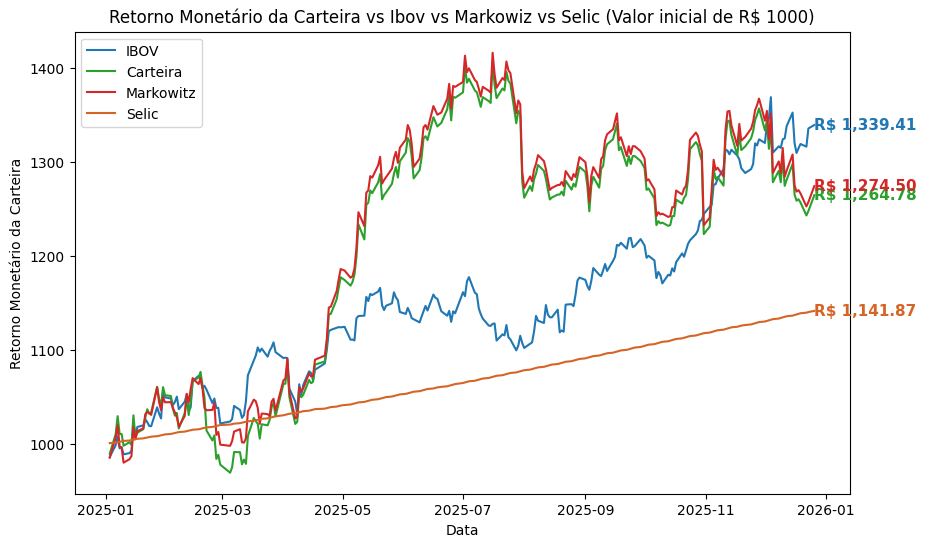

In [100]:
from matplotlib import pyplot as plt
plt.figure(figsize=(10, 6))
cores = {'IBOV': '#1f77b4', 'Carteira': '#2ca02c', 'Markowitz': '#d62728', 'Selic': "#d66427"}
retorno_acumulado_monetario = retorno_acumulado_monetario.dropna()
for nome in ['IBOV', 
             'Carteira', 
             'Markowitz', 
             'Selic']:
    plt.plot(
            retorno_acumulado_monetario.index,
            retorno_acumulado_monetario[nome],
                label=nome,
                color=cores[nome]
            )
    ultimo_x = retorno_acumulado_monetario[nome].index[-1]
    ultimo_y = retorno_acumulado_monetario[nome].iloc[-1]
    plt.text(
                ultimo_x, ultimo_y,
                f'R$ {ultimo_y:,.2f}',
                color=cores[nome],
                fontsize=11,
                va='center',
                fontweight='bold'
            )

plt.legend()
plt.xlabel("Data")
plt.ylabel("Retorno Monetário da Carteira")
plt.title(f"Retorno Monetário da Carteira vs Ibov vs Markowiz vs Selic (Valor inicial de R$ {1000})")
plt.show()

In [ ]:
import json
import asyncio
import pandas as pd
from bcb import sgs
import pandas as pd
from sklearn.covariance import LedoitWolf
import numpy as np
from scipy.optimize import minimize
from IPython.display import display
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

    
def markowitz_opt(returns: pd.DataFrame):
    # === Estatísticas ===
    mu = returns.mean()  # retorno médio esperado
    # matriz de covariância com Ledoit–Wolf shrinkage
    lw = LedoitWolf().fit(returns)
    Sigma = lw.covariance_

    n = len(mu)

    # Retorno alvo (por exemplo, retorno médio da amostra de treino)
    target_return = mu.mean()

    # === Funções auxiliares ===
    def portfolio_performance(w, mu, Sigma):
        ret = np.dot(w, mu)
        vol = np.sqrt(np.dot(w.T, np.dot(Sigma, w)))
        return ret, vol

    def objective(w, mu, Sigma, target):
        ret, vol = portfolio_performance(w, mu, Sigma)
        return vol  # minimiza a volatilidade

    # === Restrições ===
    constraints = (
        {'type': 'eq', 'fun': lambda w: np.sum(w) - 1},              # soma = 1
        {'type': 'eq', 'fun': lambda w: np.dot(w, mu) - target_return},  # retorno alvo
    )
    bounds = tuple((0, 1) for _ in range(n))  # sem short

    # === Otimização ===
    w0 = np.repeat(1/n, n)
    opt = minimize(
        objective, w0, args=(mu, Sigma, target_return),
        method='SLSQP', bounds=bounds, constraints=constraints
    )

    weights = opt.x

    # === Aplicação dos pesos ao conjunto de retornos ===
    markowitz_cr = (1 + (weights * returns).sum(axis=1)).cumprod()

    weights_markowitz = pd.DataFrame(
        np.tile(weights, (len(returns), 1)),  # repete o vetor em todas as linhas
        index=returns.index,
        columns=returns.columns
    )

    return weights_markowitz, markowitz_cr

def get_selic_multiplos_periodos(data_inicio, data_fim, anos_por_janela=5):
    """
    Busca dados da SELIC em janelas de X anos para contornar limitação da API
    """
    inicio = pd.to_datetime(data_inicio)
    fim = pd.to_datetime(data_fim)
    
    # Lista para armazenar os dataframes
    dados_completos = []
    
    # Criar janelas
    current_start = inicio
    
    while current_start < fim:
        current_end = min(current_start + pd.DateOffset(years=anos_por_janela), fim)
        
        print(f"Buscando dados de {current_start.date()} até {current_end.date()}...")
        
        try:
            # Fazer requisição para a janela atual
            dados_janela = sgs.get({'selic': 11, 
                                    #'cdi' :12
                                    }, 
                                   start=current_start.strftime('%Y-%m-%d'),
                                   end=current_end.strftime('%Y-%m-%d'))
            
            dados_completos.append(dados_janela)
            print(f"  ✓ {len(dados_janela)} registros obtidos")
            
        except Exception as e:
            print(f"  ✗ Erro ao buscar dados: {e}")

        current_start = current_end + pd.Timedelta(days=1)

    if dados_completos:
        selic_completo = pd.concat(dados_completos)
        selic_completo = selic_completo[~selic_completo.index.duplicated(keep='first')]
        selic_completo = selic_completo.sort_index()
        
        print(f"\n✓ Total de registros: {len(selic_completo)}")
        print(f"✓ Período: {selic_completo.index.min().date()} até {selic_completo.index.max().date()}")
        
        return selic_completo
    else:
        print("Nenhum dado foi obtido!")
        return None
    
def daily_returns(prices):
    return prices.pct_change()[1:]

def daily_returns_carteira(prices, pesos):
    pesos_porcentagem = pesos_porcentagem = [peso/100 for peso in pesos]
    variacao_diaria_carteira = (prices.pct_change()[1:] * (pesos_porcentagem)).sum(axis=1)
    return variacao_diaria_carteira

def annualized_volatility(daily_ret, trading_days=252):
    return daily_ret.std() * np.sqrt(trading_days)

def annualized_mean_return(daily_ret, trading_days=252):
    return daily_ret.mean() * trading_days

def cagr(prices):
    days = (prices.index[-1] - prices.index[0]).days
    years = days / 365.25
    return (prices.iloc[-1] / prices.iloc[0])**(1/years) - 1 if years > 0 else np.nan

def max_drawdown(prices):
    cum_max = prices.cummax()
    drawdowns = (prices - cum_max) / cum_max
    return drawdowns.min()

def avg_drawdown(prices):
    dd = (prices / prices.cummax()) - 1
    negatives = dd < 0
    groups = (negatives.astype(int).diff() != 0).cumsum()
    avg_dds = []
    for _, grp in dd.groupby(groups):
        if (grp < 0).any():
            avg_dds.append(grp.min())
    return np.mean(avg_dds) if avg_dds else 0.0

def calmar_ratio(prices):
    ann_ret = cagr(prices)
    mdd = max_drawdown(prices)
    return ann_ret / abs(mdd) if mdd != 0 else np.nan

def sortino_ratio(daily_ret, required_return=0.0, trading_days=252):
    rr_daily = (1 + required_return)**(1/trading_days) - 1
    downside = daily_ret[daily_ret < rr_daily] - rr_daily
    if downside.size == 0:
        return np.nan
    dd = np.sqrt((downside**2).mean()) * np.sqrt(trading_days)
    ann_ret = annualized_mean_return(daily_ret, trading_days)
    return (ann_ret - required_return) / dd if dd != 0 else np.nan

def compute_metrics(price_df):
    metrics = {}
    for col in price_df.columns:
        p = price_df[col].dropna()
        #dr = daily_returns_carteira(p, pesos)
        metrics[col] = {
            "ann_vol": annualized_volatility(p),
            "ann_mean_ret": annualized_mean_return(p),
            "cagr": cagr(p),
            "max_drawdown": max_drawdown(p),
            "avg_drawdown": avg_drawdown(p),
            "calmar": calmar_ratio(p),
            "sortino": sortino_ratio(p)
        }
    return pd.DataFrame(metrics).T


def normalizar_pesos(weights_dict, target_sum=100, tolerancia=0.01):
    """
    Normaliza os pesos para somarem exatamente o target_sum.
    
    Args:
        weights_dict: Dicionário com os pesos {ticker: peso}
        target_sum: Soma alvo (padrão: 100)
        tolerancia: Tolerância para considerar soma correta (padrão: 0.01)
    
    Returns:
        Dicionário com pesos normalizados
    """
    total_atual = sum(weights_dict.values())
    diferenca = abs(total_atual - target_sum)
    
    # Se já está dentro da tolerância, retorna o original
    if diferenca <= tolerancia:
        logger.info(f"✓ Pesos já somam {total_atual:.2f}% (dentro da tolerância)")
        return weights_dict
    
    # Normalização proporcional (melhor que distribuir igualmente)
    fator_normalizacao = target_sum / total_atual
    weights_normalizados = {
        ticker: peso * fator_normalizacao 
        for ticker, peso in weights_dict.items()
    }
    
    # Log da correção
    logger.warning(
        f"⚠ Pesos ajustados: {total_atual:.2f}% → {target_sum:.2f}% "
        f"(fator: {fator_normalizacao:.4f})"
    )
    
    # Verificação final
    soma_final = sum(weights_normalizados.values())
    logger.info(f"✓ Soma final: {soma_final:.4f}%")
    
    return weights_normalizados

class ComputandoMetricas:
    def __init__(self, data_inicio, 
                 data_fim, 
                 carteira,
                 valor_investido=1000):
        self.data_inicio = data_inicio
        self.data_fim = data_fim
        self.carteira = carteira
        self.valor_investido = valor_investido
        self.ibov, self.df = self.carregando_dados()
        self.tics_selecionados, self.pesos_carteira = self.ajustando_pesos_carteira()
    
        
    def carregando_dados(self):
        tics_selecionados = [tic if tic.endswith(".SA") else f"{tic}.SA" for tic in self.carteira.keys()]
        ibov = yf.download("^BVSP", start=self.data_inicio, end=self.data_fim)["Close"]
        df = yf.download(tics_selecionados, start=self.data_inicio, end=self.data_fim)["Close"]
        df.dropna(axis=1, how='all', inplace=True)
        return ibov, df
    
    def cumulative_returns(self):
        return (self.df.apply(daily_returns)+1).cumprod()
    
    def ajustando_pesos_carteira(self):
        dict_carteiras = self.carteira.copy()
        tic_validos = list(self.df.columns)
        carteira_valida = {key: value for key, value in dict_carteiras.items() if key + ".SA" in tic_validos}
        carteira_pesos_acoes_validos = normalizar_pesos(carteira_valida)
        tics_selecionados = list(carteira_pesos_acoes_validos.keys())
        pesos = list(carteira_pesos_acoes_validos.values()) 
        return tics_selecionados, pesos
        
    def computando_marcowitz(self):
        weights_markowitz, markowitz_cr = markowitz_opt(self.df.pct_change().dropna())
        return weights_markowitz, markowitz_cr
        
    def daily_returns_carteira_markowitz(self):
        weights_markowitz, markowitz_cr = self.computando_marcowitz()
        pesos_markowitz = [peso*100 for peso in weights_markowitz.iloc[-1].to_list()]
        retornos_carteira_markowitz = daily_returns_carteira(self.df, pesos_markowitz)
        return retornos_carteira_markowitz
    
    def retornos_diarios_carteira(self):
        retornos_diarios_carteira = daily_returns_carteira(self.df, self.pesos_carteira)
        return retornos_diarios_carteira
    
    def retornos_diarios_ibov(self):
        retorno_diario = self.ibov.pct_change()[1:]
        return retorno_diario
    
    def data_frame_comparacao_retorno_diario(self):
        retornos_carteira = self.retornos_diarios_carteira()
        retornos_ibov = self.retornos_diarios_ibov()
        retornos_markowitz = self.daily_returns_carteira_markowitz()
        comparacao_carteira = pd.concat([retornos_carteira, 
                                 retornos_ibov, 
                                 retornos_markowitz], axis=1,).rename(columns={0: "Carteira", 
                                                                               "^BVSP": "IBOV", 
                                                                               1: "Markowitz"})
        return comparacao_carteira
    
    def metrica_comparacao_carteira_ibov_retornos_markowitz(self):
        comparacao_carteira = self.data_frame_comparacao_retorno_diario()
        comp_metrics = compute_metrics(comparacao_carteira)
        return comp_metrics
    
    def retorno_menetario_ibov(self):
        ibov_retornos = (self.ibov.pct_change()[1:]+1).cumprod() *self.valor_investido
        return ibov_retornos
    
    def retorno_carteira_monetario(self):
        pesos_frac = [p/100 for p in self.pesos_carteira]
        valor_investido_carteira = [self.valor_investido * peso for peso in pesos_frac]
        retorno_carteira = (self.cumulative_returns() * valor_investido_carteira).sum(axis=1)
        return retorno_carteira
    
    def data_frame_comparacao_retorno_monetario(self):
        ibov_retornos = self.retorno_menetario_ibov()
        retorno_carteira = self.retorno_carteira_monetario()
        _ , markowitz_cr = self.computando_marcowitz()
        selic = self.retorno_selic()

        retorno_acumulado_monetario = pd.concat([ibov_retornos, retorno_carteira, markowitz_cr*self.valor_investido, selic], axis=1).rename(columns={"^BVSP": "IBOV", 0: "Carteira", 1: "Markowitz", "selic":"Selic"})
        return retorno_acumulado_monetario
    
    def retorno_selic(self):
        selic = get_selic_multiplos_periodos(self.data_inicio, self.data_fim)
        selic_acumulada =  ((selic/100 + 1).cumprod())*self.valor_investido
        return selic_acumulada
    
    def print_results(self, save_path="../data/"):
        import os
        from datetime import datetime
        
        # Criar diretório se não existir
        os.makedirs(save_path, exist_ok=True)
    
        
        metrics = self.metrica_comparacao_carteira_ibov_retornos_markowitz()
        retorno_acumulado_monetario = self.data_frame_comparacao_retorno_monetario()
        
        print("\n" + "="*40)
        print("📊 Métricas de Comparação das Carteiras")
        print("="*40)
        
        # Salvar métricas em CSV
        metrics_file = os.path.join(save_path, "metricas.csv")
        metrics.to_csv(metrics_file)
        print(f"✅ Métricas salvas em: {metrics_file}")
    
        display(metrics.style.set_caption("Métricas das Carteiras").background_gradient(cmap="Blues"))
    
        plt.figure(figsize=(10, 6))
        cores = {'IBOV': '#1f77b4', 'Carteira': '#2ca02c', 'Markowitz': '#d62728', 'Selic': "#d66427"}

        for nome in ['IBOV', 'Carteira', 'Markowitz', 'Selic']:
            plt.plot(
                retorno_acumulado_monetario.index,
                retorno_acumulado_monetario[nome],
                label=nome,
                color=cores[nome]
            )
            ultimo_x = retorno_acumulado_monetario.index[-2]
            ultimo_y = retorno_acumulado_monetario[nome].iloc[-2]
            plt.text(
                ultimo_x, ultimo_y,
                f'R$ {ultimo_y:,.2f}',
                color=cores[nome],
                fontsize=11,
                va='center',
                fontweight='bold'
            )

        plt.legend()
        plt.xlabel("Data")
        plt.ylabel("Retorno Monetário da Carteira")
        plt.title(f"Retorno Monetário da Carteira vs Ibov vs Markowitz (Valor inicial de R$ {self.valor_investido})")
        
        # Salvar gráfico
        grafico_file = os.path.join(save_path, f"grafico_retornos.png")
        plt.savefig(grafico_file, dpi=300, bbox_inches='tight')
        print(f"✅ Gráfico salvo em: {grafico_file}")
        
        plt.show()
        
        # Salvar retornos acumulados em CSV
        retornos_file = os.path.join(save_path, f"retornos_acumulados.csv")
        retorno_acumulado_monetario.to_csv(retornos_file)
        print(f"✅ Retornos acumulados salvos em: {retornos_file}")
        
        print("\n" + "="*40)
        
        return retorno_acumulado_monetario

In [ ]:
with open("../data/carteira_resultado.json", "r") as f:
    carteira_resultado = json.load(f)
comp = ComputandoMetricas("2025-01-01", "2025-12-31",carteira_resultado['tickers_weights'] ,100000)
ibov, df = comp.carregando_dados()

C:\Users\jefer\AppData\Local\Temp\ipykernel_28464\1208338735.py:129: RuntimeWarning: invalid value encountered in scalar power
  return (prices.iloc[-1] / prices.iloc[0])**(1/years) - 1 if years > 0 else np.nan
C:\Users\jefer\AppData\Local\Temp\ipykernel_28464\1208338735.py:129: RuntimeWarning: invalid value encountered in scalar power
  return (prices.iloc[-1] / prices.iloc[0])**(1/years) - 1 if years > 0 else np.nan
C:\Users\jefer\AppData\Local\Temp\ipykernel_28464\1208338735.py:129: RuntimeWarning: invalid value encountered in scalar power
  return (prices.iloc[-1] / prices.iloc[0])**(1/years) - 1 if years > 0 else np.nan
C:\Users\jefer\AppData\Local\Temp\ipykernel_28464\1208338735.py:129: RuntimeWarning: invalid value encountered in scalar power
  return (prices.iloc[-1] / prices.iloc[0])**(1/years) - 1 if years > 0 else np.nan


Buscando dados de 2025-01-01 até 2025-12-31...
  ✓ 246 registros obtidos

✓ Total de registros: 246
✓ Período: 2025-01-02 até 2025-12-22

📊 Métricas de Comparação das Carteiras
✅ Métricas salvas em: ../data/metricas.csv


c:\Users\jefer\Documents\Ciencia-de-dados\LLMs\Agent-Portfolio-Optimizer\.venv\Lib\site-packages\pandas\io\formats\style.py:3807: RuntimeWarning: All-NaN slice encountered
  smin = np.nanmin(gmap) if vmin is None else vmin
c:\Users\jefer\Documents\Ciencia-de-dados\LLMs\Agent-Portfolio-Optimizer\.venv\Lib\site-packages\pandas\io\formats\style.py:3808: RuntimeWarning: All-NaN slice encountered
  smax = np.nanmax(gmap) if vmax is None else vmax


,ann_vol,ann_mean_ret,cagr,max_drawdown,avg_drawdown,calmar,sortino
Carteira,0.146009,0.321309,nan,-2.577188,-2.051411,nan,2.307027
IBOV,0.152895,0.307646,nan,-2.382162,-1.963529,nan,2.089908
Markowitz,0.129777,0.291968,nan,-1.977437,-1.715316,nan,2.374702


✅ Gráfico salvo em: ../data/grafico_retornos.png


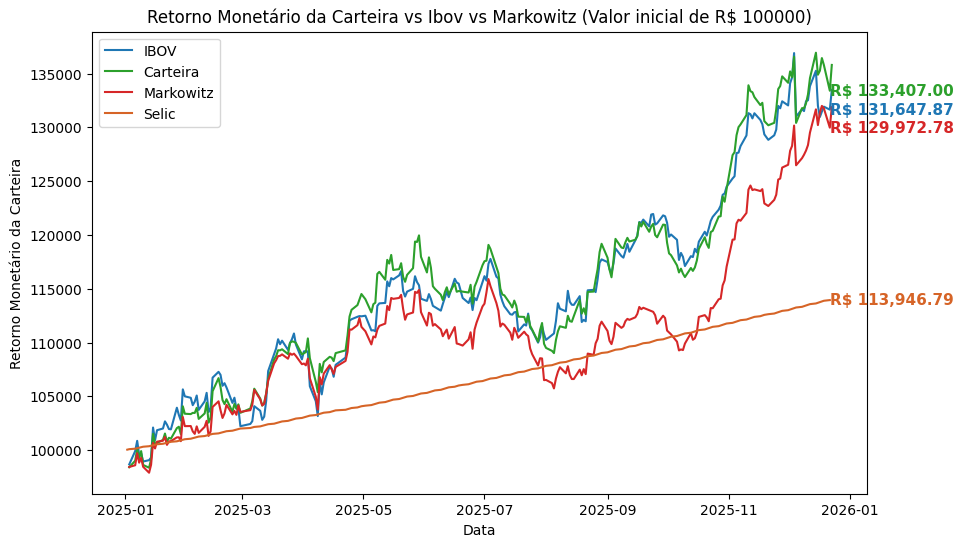

✅ Retornos acumulados salvos em: ../data/retornos_acumulados.csv



In [ ]:
carteira_tempo = comp.print_results()

In [ ]:

tics_selecionados = list(carteira_resultado['tickers_weights'].keys())

tics_selecionados_sa = [tic + ".SA" if not tic.endswith(".SA") else tic for tic in tics_selecionados]
print(tics_selecionados_sa)

df = yf.download(tics_selecionados_sa, start="2025-01-01")["Close"]

pesos = list(carteira_resultado['tickers_weights'].values()) 

comp = ComputandoMetricas("2025-01-01", "2025-12-31", tics_selecionados_sa, pesos, 100000)

#carteira_tempo = comp.print_results()

#carteira_tempo.to_csv("avaliacao_carteira.csv")

['ABEV3.SA', 'BBDC4.SA', 'BBAS3.SA', 'BRAP4.SA', 'CMIG3.SA', 'CSUD3.SA', 'EGIE3.SA', 'FIQE3.SA', 'WEGE3.SA']


C:\Users\jefer\AppData\Local\Temp\ipykernel_28464\3444372168.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(tics_selecionados_sa, start="2025-01-01")["Close"]
[*********************100%***********************]  9 of 9 completed
C:\Users\jefer\AppData\Local\Temp\ipykernel_28464\1549867255.py:190: FutureWarning: YF.download() has changed argument auto_adjust default to True
  ibov = yf.download("^BVSP", start=self.data_inicio, end=self.data_fim)["Close"]
[*********************100%***********************]  1 of 1 completed
C:\Users\jefer\AppData\Local\Temp\ipykernel_28464\1549867255.py:191: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(self.tics_selecionados, start=self.data_inicio, end=self.data_fim)["Close"]
[*********************100%***********************]  9 of 9 completed


In [ ]:
carteira_tempo = comp.print_results()

In [ ]:
import json
import asyncio
import pandas as pd
from bcb import sgs
import pandas as pd
from sklearn.covariance import LedoitWolf
import numpy as np
from scipy.optimize import minimize
from IPython.display import display
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
import logging

logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

    
def markowitz_opt(returns: pd.DataFrame):
    # === Estatísticas ===
    mu = returns.mean()  # retorno médio esperado
    # matriz de covariância com Ledoit–Wolf shrinkage
    lw = LedoitWolf().fit(returns)
    Sigma = lw.covariance_

    n = len(mu)

    # Retorno alvo (por exemplo, retorno médio da amostra de treino)
    target_return = mu.mean()

    # === Funções auxiliares ===
    def portfolio_performance(w, mu, Sigma):
        ret = np.dot(w, mu)
        vol = np.sqrt(np.dot(w.T, np.dot(Sigma, w)))
        return ret, vol

    def objective(w, mu, Sigma, target):
        ret, vol = portfolio_performance(w, mu, Sigma)
        return vol  # minimiza a volatilidade

    # === Restrições ===
    constraints = (
        {'type': 'eq', 'fun': lambda w: np.sum(w) - 1},              # soma = 1
        {'type': 'eq', 'fun': lambda w: np.dot(w, mu) - target_return},  # retorno alvo
    )
    bounds = tuple((0, 1) for _ in range(n))  # sem short

    # === Otimização ===
    w0 = np.repeat(1/n, n)
    opt = minimize(
        objective, w0, args=(mu, Sigma, target_return),
        method='SLSQP', bounds=bounds, constraints=constraints
    )

    weights = opt.x

    # === Aplicação dos pesos ao conjunto de retornos ===
    markowitz_cr = (1 + (weights * returns).sum(axis=1)).cumprod()

    weights_markowitz = pd.DataFrame(
        np.tile(weights, (len(returns), 1)),  # repete o vetor em todas as linhas
        index=returns.index,
        columns=returns.columns
    )

    return weights_markowitz, markowitz_cr

def get_selic_multiplos_periodos(data_inicio, data_fim, anos_por_janela=5):
    """
    Busca dados da SELIC em janelas de X anos para contornar limitação da API
    """
    inicio = pd.to_datetime(data_inicio)
    fim = pd.to_datetime(data_fim)
    
    # Lista para armazenar os dataframes
    dados_completos = []
    
    # Criar janelas
    current_start = inicio
    
    while current_start < fim:
        current_end = min(current_start + pd.DateOffset(years=anos_por_janela), fim)
        
        print(f"Buscando dados de {current_start.date()} até {current_end.date()}...")
        
        try:
            # Fazer requisição para a janela atual
            dados_janela = sgs.get({'selic': 11, 
                                    #'cdi' :12
                                    }, 
                                   start=current_start.strftime('%Y-%m-%d'),
                                   end=current_end.strftime('%Y-%m-%d'))
            
            dados_completos.append(dados_janela)
            print(f"  ✓ {len(dados_janela)} registros obtidos")
            
        except Exception as e:
            print(f"  ✗ Erro ao buscar dados: {e}")

        current_start = current_end + pd.Timedelta(days=1)

    if dados_completos:
        selic_completo = pd.concat(dados_completos)
        selic_completo = selic_completo[~selic_completo.index.duplicated(keep='first')]
        selic_completo = selic_completo.sort_index()
        
        print(f"\n✓ Total de registros: {len(selic_completo)}")
        print(f"✓ Período: {selic_completo.index.min().date()} até {selic_completo.index.max().date()}")
        
        return selic_completo
    else:
        print("Nenhum dado foi obtido!")
        return None
    
def daily_returns(prices):
    return prices.pct_change()[1:]

def daily_returns_carteira(prices, pesos):
    pesos_porcentagem = pesos_porcentagem = [peso/100 for peso in pesos]
    variacao_diaria_carteira = (prices.pct_change()[1:] * (pesos_porcentagem)).sum(axis=1)
    return variacao_diaria_carteira

def annualized_volatility(daily_ret, trading_days=252):
    return daily_ret.std() * np.sqrt(trading_days)

def annualized_mean_return(daily_ret, trading_days=252):
    return daily_ret.mean() * trading_days

def cagr(prices):
    days = (prices.index[-1] - prices.index[0]).days
    years = days / 365.25
    return (prices.iloc[-1] / prices.iloc[0])**(1/years) - 1 if years > 0 else np.nan

def max_drawdown(prices):
    cum_max = prices.cummax()
    drawdowns = (prices - cum_max) / cum_max
    return drawdowns.min()

def avg_drawdown(prices):
    dd = (prices / prices.cummax()) - 1
    negatives = dd < 0
    groups = (negatives.astype(int).diff() != 0).cumsum()
    avg_dds = []
    for _, grp in dd.groupby(groups):
        if (grp < 0).any():
            avg_dds.append(grp.min())
    return np.mean(avg_dds) if avg_dds else 0.0

def calmar_ratio(prices):
    ann_ret = cagr(prices)
    mdd = max_drawdown(prices)
    return ann_ret / abs(mdd) if mdd != 0 else np.nan

def sortino_ratio(daily_ret, required_return=0.0, trading_days=252):
    rr_daily = (1 + required_return)**(1/trading_days) - 1
    downside = daily_ret[daily_ret < rr_daily] - rr_daily
    if downside.size == 0:
        return np.nan
    dd = np.sqrt((downside**2).mean()) * np.sqrt(trading_days)
    ann_ret = annualized_mean_return(daily_ret, trading_days)
    return (ann_ret - required_return) / dd if dd != 0 else np.nan

def compute_metrics(price_df):
    metrics = {}
    for col in price_df.columns:
        p = price_df[col].dropna()
        #dr = daily_returns_carteira(p, pesos)
        metrics[col] = {
            "ann_vol": annualized_volatility(p),
            "ann_mean_ret": annualized_mean_return(p),
            "cagr": cagr(p),
            "max_drawdown": max_drawdown(p),
            "avg_drawdown": avg_drawdown(p),
            "calmar": calmar_ratio(p),
            "sortino": sortino_ratio(p)
        }
    return pd.DataFrame(metrics).T


def normalizar_pesos(weights_dict, target_sum=100, tolerancia=0.01):
    """
    Normaliza os pesos para somarem exatamente o target_sum.
    
    Args:
        weights_dict: Dicionário com os pesos {ticker: peso}
        target_sum: Soma alvo (padrão: 100)
        tolerancia: Tolerância para considerar soma correta (padrão: 0.01)
    
    Returns:
        Dicionário com pesos normalizados
    """
    total_atual = sum(weights_dict.values())
    diferenca = abs(total_atual - target_sum)
    
    # Se já está dentro da tolerância, retorna o original
    if diferenca <= tolerancia:
        logger.info(f"✓ Pesos já somam {total_atual:.2f}% (dentro da tolerância)")
        return weights_dict
    
    # Normalização proporcional (melhor que distribuir igualmente)
    fator_normalizacao = target_sum / total_atual
    weights_normalizados = {
        ticker: peso * fator_normalizacao 
        for ticker, peso in weights_dict.items()
    }
    
    # Log da correção
    logger.warning(
        f"⚠ Pesos ajustados: {total_atual:.2f}% → {target_sum:.2f}% "
        f"(fator: {fator_normalizacao:.4f})"
    )
    
    # Verificação final
    soma_final = sum(weights_normalizados.values())
    logger.info(f"✓ Soma final: {soma_final:.4f}%")
    
    return weights_normalizados

class ComputandoMetricas:
    def __init__(self, data_inicio, 
                 data_fim, 
                 carteira,
                 valor_investido=1000):
        self.data_inicio = data_inicio
        self.data_fim = data_fim
        self.carteira = carteira
        self.valor_investido = valor_investido
        self.ibov, self.df = self.carregando_dados()
        self.tics_selecionados, self.pesos_carteira = self.ajustando_pesos_carteira()
    
        
    def carregando_dados(self):
        tics_selecionados = [tic if tic.endswith(".SA") else f"{tic}.SA" for tic in self.carteira.keys()]
        ibov = yf.download("^BVSP", start=self.data_inicio, end=self.data_fim)["Close"]
        df = yf.download(tics_selecionados, start=self.data_inicio, end=self.data_fim)["Close"]
        df.dropna(axis=1, how='all', inplace=True)
        return ibov, df
    
    def cumulative_returns(self):
        return (self.df.apply(daily_returns)+1).cumprod()
    
    def ajustando_pesos_carteira(self):
        dict_carteiras = self.carteira.copy()
        tic_validos = list(self.df.columns)
        carteira_valida = {
            key: value for key, value in dict_carteiras.items()
            if (key.endswith(".SA") and key in tic_validos) or 
            (not key.endswith(".SA") and key + ".SA" in tic_validos)
        }
        
        carteira_pesos_acoes_validos = normalizar_pesos(carteira_valida)
        tics_selecionados = list(carteira_pesos_acoes_validos.keys())
        pesos = list(carteira_pesos_acoes_validos.values()) 
        return tics_selecionados, pesos
        
    def computando_marcowitz(self):
        weights_markowitz, markowitz_cr = markowitz_opt(self.df.pct_change().dropna())
        return weights_markowitz, markowitz_cr
        
    def daily_returns_carteira_markowitz(self):
        weights_markowitz, markowitz_cr = self.computando_marcowitz()
        pesos_markowitz = [peso*100 for peso in weights_markowitz.iloc[-1].to_list()]
        retornos_carteira_markowitz = daily_returns_carteira(self.df, pesos_markowitz)
        return retornos_carteira_markowitz
    
    def retornos_diarios_carteira(self):
        retornos_diarios_carteira = daily_returns_carteira(self.df, self.pesos_carteira)
        return retornos_diarios_carteira
    
    def retornos_diarios_ibov(self):
        retorno_diario = self.ibov.pct_change()[1:]
        return retorno_diario
    
    def data_frame_comparacao_retorno_diario(self):
        retornos_carteira = self.retornos_diarios_carteira()
        retornos_ibov = self.retornos_diarios_ibov()
        retornos_markowitz = self.daily_returns_carteira_markowitz()
        comparacao_carteira = pd.concat([retornos_carteira, 
                                 retornos_ibov, 
                                 retornos_markowitz], axis=1,).rename(columns={0: "Carteira", 
                                                                               "^BVSP": "IBOV", 
                                                                               1: "Markowitz"})
        return comparacao_carteira
    
    def metrica_comparacao_carteira_ibov_retornos_markowitz(self):
        comparacao_carteira = self.data_frame_comparacao_retorno_diario()
        comp_metrics = compute_metrics(comparacao_carteira)
        return comp_metrics
    
    def retorno_menetario_ibov(self):
        ibov_retornos = (self.ibov.pct_change()[1:]+1).cumprod() *self.valor_investido
        return ibov_retornos
    
    def retorno_carteira_monetario(self):
        pesos_frac = [p/100 for p in self.pesos_carteira]
        valor_investido_carteira = [self.valor_investido * peso for peso in pesos_frac]
        retorno_carteira = (self.cumulative_returns() * valor_investido_carteira).sum(axis=1)
        return retorno_carteira
    
    def data_frame_comparacao_retorno_monetario(self):
        ibov_retornos = self.retorno_menetario_ibov()
        retorno_carteira = self.retorno_carteira_monetario()
        _ , markowitz_cr = self.computando_marcowitz()
        selic = self.retorno_selic()

        retorno_acumulado_monetario = pd.concat([ibov_retornos, retorno_carteira, markowitz_cr*self.valor_investido, selic], axis=1).rename(columns={"^BVSP": "IBOV", 0: "Carteira", 1: "Markowitz", "selic":"Selic"})
        return retorno_acumulado_monetario
    
    def retorno_selic(self):
        selic = get_selic_multiplos_periodos(self.data_inicio, self.data_fim)
        selic_acumulada =  ((selic/100 + 1).cumprod())*self.valor_investido
        return selic_acumulada
    
    def print_results(self, save_path="../data/"):
        import os
        from datetime import datetime
        
        # Criar diretório se não existir
        os.makedirs(save_path, exist_ok=True)
    
        
        metrics = self.metrica_comparacao_carteira_ibov_retornos_markowitz()
        retorno_acumulado_monetario = self.data_frame_comparacao_retorno_monetario()
        
        print("\n" + "="*40)
        print("📊 Métricas de Comparação das Carteiras")
        print("="*40)
        
        # Salvar métricas em CSV
        metrics_file = os.path.join(save_path, "metricas.csv")
        metrics.to_csv(metrics_file)
        print(f"✅ Métricas salvas em: {metrics_file}")
    
        display(metrics.style.set_caption("Métricas das Carteiras").background_gradient(cmap="Blues"))
    
        plt.figure(figsize=(10, 6))
        cores = {'IBOV': '#1f77b4', 'Carteira': '#2ca02c', 'Markowitz': '#d62728', 'Selic': "#d66427"}

        for nome in ['IBOV', 'Carteira', 'Markowitz', 'Selic']:
            plt.plot(
                retorno_acumulado_monetario.index,
                retorno_acumulado_monetario[nome],
                label=nome,
                color=cores[nome]
            )
            ultimo_x = retorno_acumulado_monetario.index[-2]
            ultimo_y = retorno_acumulado_monetario[nome].iloc[-2]
            plt.text(
                ultimo_x, ultimo_y,
                f'R$ {ultimo_y:,.2f}',
                color=cores[nome],
                fontsize=11,
                va='center',
                fontweight='bold'
            )

        plt.legend()
        plt.xlabel("Data")
        plt.ylabel("Retorno Monetário da Carteira")
        plt.title(f"Retorno Monetário da Carteira vs Ibov vs Markowitz (Valor inicial de R$ {self.valor_investido})")
        
        # Salvar gráfico
        grafico_file = os.path.join(save_path, f"grafico_retornos.png")
        plt.savefig(grafico_file, dpi=300, bbox_inches='tight')
        print(f"✅ Gráfico salvo em: {grafico_file}")
        
        plt.show()
        
        # Salvar retornos acumulados em CSV
        retornos_file = os.path.join(save_path, f"retornos_acumulados.csv")
        retorno_acumulado_monetario.to_csv(retornos_file)
        print(f"✅ Retornos acumulados salvos em: {retornos_file}")
        
        print("\n" + "="*40)
        
        return retorno_acumulado_monetario

with open("../data/carteira_resultado.json", "r") as f:
    carteira_resultado = json.load(f)
    
comp = ComputandoMetricas("2025-01-01", "2025-12-31",carteira_resultado['tickers_weights'] ,100000)

comp.print_results(save_path="../data/")

In [ ]:
import pandas as pd
import logging
import warnings
from langchain_nvidia_ai_endpoints import ChatNVIDIA 
from dotenv import load_dotenv
import json

load_dotenv()

warnings.filterwarnings("ignore")

logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

#carteira_atual = pd.read_csv("../data/resultado_carteira_futuro/resultado_carteira_atual.csv", index_col=0)

try:
    with open('../README.md', 'r', encoding='utf-8') as file:
        readme_content = file.readlines()
except UnicodeDecodeError:
    with open('../README.md', 'r', encoding='latin-1') as file:
        readme_content = file.readlines()
        

c:\Users\jefer\Documents\Ciencia-de-dados\LLMs\Agent-Portfolio-Optimizer\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import pandas as pd
url = "https://raw.githubusercontent.com/Jeferson100/fundamentalist-stock-brazil/main/dados/setor.csv"
setor = pd.read_csv(url, index_col=0, parse_dates=True)
setor_markdown = setor.to_markdown()

for i, line in enumerate(readme_content):
    if '## Lista de ações avaliadas' in line:
        index_inicio = i
    if '## Estrutura do projeto' in line:
        index_fim = i

readme_content = readme_content[:index_inicio+1] + readme_content[index_fim-1:]
        
readme_content.insert(index_inicio + 1, f"\n{setor_markdown}\n\n\n")
readme_content = ''.join(readme_content)

In [3]:
from IPython.display import display, Markdown

display(Markdown(readme_content))

# Agent Portfolio Optimizer

|||
|-----------|-----------|
| **Testing**  | [![Testes CI e CD](https://github.com/Jeferson100/Agent-Portfolio-Optimizer/actions/workflows/testes_ci_cd.yml/badge.svg)](https://github.com/Jeferson100/Agent-Portfolio-Optimizer/actions/workflows/testes_ci_cd.yml) ||
| **Tecnologias**  | ![Python](https://img.shields.io/badge/Python-3.12%2B-blue?style=flat&logo=python) [![LangGraph](https://img.shields.io/badge/LangGraph-gray?style=flat&logo=langgraph&logoColor=white)](https://langchain-ai.github.io/langgraph/) [![LangChain](https://img.shields.io/badge/LangChain-gray?style=flat&logo=langchain&logoColor=white)](https://www.langchain.com/)  ![Pydantic](https://img.shields.io/badge/Pydantic-gray?style=flat&logo=pydantic&logoColor=purple) [![HuggingFace](https://img.shields.io/badge/HuggingFace-gray?style=flat&logo=huggingface)](https://huggingface.co/)  ![NVIDIA](https://img.shields.io/badge/-NVIDIA-gray?logo=nvidia) [![Cerebras](https://img.shields.io/badge/-Cerebras-gray?logo=cerebras/)](https://www.cerebras.ai/) [![Groq](https://img.shields.io/badge/Groq-gray?style=flat&logo=groq&logoColor=white)](https://groq.com/) ![Pandas](https://img.shields.io/badge/pandas-gray?style=flat&logo=pandas&logoColor=150458)
||

## Visão geral

**Agent Portfolio Optimizer** é uma solução inteligente em Python que automatiza a análise fundamentalista de ações brasileiras (B3) utilizando Large Language Models (LLMs). O sistema avalia empresas, classifica ativos por qualidade e constrói carteiras otimizadas através de uma arquitetura multi-agente baseada em **LangGraph**, onde cada agente especializado contribui para decisões de investimento fundamentadas e diversificadas. 

Primero um agente avalia os ativos classificando-os por qualidade atraves dos dados fundamentais, essa classificacao pode ser `Excellent`, `Good`, `Fair`, `Poor` ou `Very Poor`, depois outro agente cria uma carteira de ações com os ativos com qualidade `Excellent` e `Good` tendo como restrição que ativos de maior peso devem ser de 20% da carteira e ativos de menor peso devem ser de 5% da carteira.


## Carteria de ações para o trimestre
### Tabela Resultados
|        |   preco_inicial(2026-01-02) |   preco_atual(2026-01-21) |   pesos_carteira |   diferenca_inicio_atual |   diferenca_inicio_atual(em %) |   valor_inicial_investido_1000 |   valor_atual_investido_1000 |
|:-------|----------------------------:|--------------------------:|-----------------:|-------------------------:|-------------------------------:|-------------------------------:|-----------------------------:|
| MULT3  |                       27.04 |                     30.36 |             0.18 |                     3.32 |                         0.1228 |                            180 |                       202.1  |
| BMOB3  |                       22    |                     23.84 |             0.09 |                     1.84 |                         0.0836 |                             90 |                        97.52 |
| ALOS3  |                       28.26 |                     28.85 |             0.09 |                     0.59 |                         0.0209 |                             90 |                        91.88 |
| CLSC4  |                      124.95 |                    135.98 |             0.07 |                    11.03 |                         0.0883 |                             70 |                        76.18 |
| CGRA4  |                       27.3  |                     26.13 |             0.07 |                    -1.17 |                        -0.0429 |                             70 |                        67    |
| WEGE3  |                       48.25 |                     47.59 |             0.07 |                    -0.66 |                        -0.0137 |                             70 |                        69.04 |
| ALPA3  |                       10.38 |                     10.13 |             0.07 |                    -0.25 |                        -0.0241 |                             70 |                        68.31 |
| ENEV3  |                       20.02 |                     21.55 |             0.07 |                     1.53 |                         0.0764 |                             70 |                        75.35 |
| FIQE3  |                        4.89 |                      5.04 |             0.07 |                     0.15 |                         0.0307 |                             70 |                        72.15 |
| SBSP3  |                      133.07 |                    130.82 |             0.07 |                    -2.25 |                        -0.0169 |                             70 |                        68.82 |
| IGTI11 |                       25.31 |                     27.23 |             0.05 |                     1.92 |                         0.0759 |                             50 |                        53.8  |
| CMIG4  |                       11.16 |                     11.16 |             0.05 |                     0    |                         0      |                             50 |                        50    |
| PRIO3  |                       41.76 |                     46.88 |             0.05 |                     5.12 |                         0.1226 |                             50 |                        56.13 |
### Comentário sobre a carteira
A carteira apresentou uma variação de 4,83% no período analisado, o que indica um desempenho positivo. Considerando que o valor investido foi de R$1.000,00 na carteira total, é possível avaliar a rentabilidade dos ativos que compõem a carteira.

Os dados fornecidos revelam que os ativos com maior peso na carteira são MULT3 (18%), BMOB3 (9%) e ALOS3 (9%). Dentre esses, MULT3 foi o que apresentou o maior ganho, com uma valorização de 12,28% (R$ 3,32 de diferença em relação ao preço inicial), contribuindo significativamente para o desempenho geral da carteira. BMOB3 e ALOS3 também apresentaram ganhos, embora menores, de 8,36% e 2,09%, respectivamente.

Além disso, é notável que alguns ativos com menor peso na carteira também apresentaram desempenhos destacados. PRIO3, por exemplo, teve uma valorização de 12,26% (R$ 5,12 de diferença), e IGTI11 valorizou 7,59% (R$ 1,92 de diferença). Outros ativos, como ENEV3 e FIQE3, também apresentaram ganhos, de 7,64% e 3,07%, respectivamente.

Por outro lado, alguns ativos apresentaram perdas no período. CGRA4, WEGE3, ALPA3 e SBSP3 registraram desvalorizações de -4,29%, -1,37%, -2,41% e -1,69%, respectivamente. No entanto, essas perdas foram compensadas pelos ganhos dos demais ativos, resultando em um desempenho geral positivo da carteira.

É importante observar que a carteira apresenta uma diversificação razoável, com ativos de diferentes setores, o que pode contribuir para a redução do risco. A presença de ativos com desempenhos variados também sugere que a estratégia de investimento adotada busca equilibrar os riscos e as oportunidades de ganho.

Considerando o desempenho geral da carteira e a valorização dos principais ativos, é possível concluir que a carteira está apresentando um desempenho satisfatório no período analisado. A variação de 4,83% é um indicador positivo, especialmente se considerarmos que o período é relativamente curto.

No entanto, é fundamental continuar monitorando o desempenho dos ativos e ajustar a estratégia de investimento conforme necessário. Além disso, é importante considerar outros fatores, como o contexto econômico e as perspectivas para os setores representados na carteira, para tomar decisões informadas e maximizar os retornos.

Em resumo, a carteira está apresentando um desempenho positivo, impulsionado principalmente pelos ganhos de MULT3, PRIO3 e outros ativos. A diversificação da carteira e a presença de ativos com desempenhos variados contribuem para um perfil de risco equilibrado. Com um acompanhamento contínuo e ajustes estratégicos, é possível manter ou melhorar o desempenho da carteira nos próximos períodos.


## 🤖 Agentes e Fluxos de Trabalho

### Agente Avaliação TICS

O agente [Avaliação TICS](https://github.com/Jeferson100/Agent-Portfolio-Optimizer/blob/main/src/portfolio_optimizer/build_langgraph/graph_avaliacao_tics.py) é responsável por processar indicadores financeiros brutos e transformá-los em inteligência de investimento. O fluxo opera sob um sistema de auto-correção que garante a qualidade da análise. O fluxo é o seguinte:

![Fluxo do agente](https://github.com/Jeferson100/Agent-Portfolio-Optimizer/raw/main/image/agente_avaliador_tics.png)

- [Coleta Fundamentalista](https://github.com/Jeferson100/Agent-Portfolio-Optimizer/blob/main/src/portfolio_optimizer/build_langgraph/nodes_avaliacao_tics.py): O primeiro nó extrai uma série histórica de 8 trimestres dos principais indicadores da empresa, incluindo:

  - Eficiência e Lucratividade: Receita Líquida, EBITDA, Margem Líquida e Lucro por Ação (LPA).

  - Endividamento: Alavancagem Financeira e Dívida Líquida/EBITDA.

  - Valuation e Fluxo de Caixa: P/L, P/VPA, Fluxo de Caixa Operacional e Variação de Caixa.

- [Analise fundamentalista](https://github.com/Jeferson100/Agent-Portfolio-Optimizer/blob/main/src/portfolio_optimizer/build_langgraph/nodes_avaliacao_tics.py): O segundo nó processa esses dados para atribuir um rating ao ativo (`Excellent`, `Good`, `Fair`, `Poor` ou `Very Poor`) acompanhado de uma justificativa.

- [Avaliação Analise](https://github.com/Jeferson100/Agent-Portfolio-Optimizer/blob/main/src/portfolio_optimizer/build_langgraph/nodes_avaliacao_tics.py): O nó Avaliação da Análise atua como um revisor, validando a coerência lógica entre os dados e a classificação dada.

Nota de Robustez: Se a análise for considerada insuficiente, o fluxo entra em um loop de reprocessamento (limitado a 4 tentativas) para garantir que apenas classificações consistentes sejam entregues ao próximo agente.

### Agente Criador de Carteira de Ações

Esse agente [Criador de Carteira de Ações](https://github.com/Jeferson100/Agent-Portfolio-Optimizer/blob/main/src/portfolio_optimizer/build_langgraph/graph_criador_carteira.py) consolida as avaliações individuais para montar um portfólio de ações brasileiras otimizado. Para maximizar a precisão e evitar a sobrecarga de contexto, o agente foca exclusivamente em ativos com selo de qualidade `Excellent` ou `Good`. O fluxo é o seguinte:

![Fluxo do agente](https://github.com/Jeferson100/Agent-Portfolio-Optimizer/raw/main/image/agente_criador_carteira.png)

Além das avaliações individuais, o agente utiliza uma matriz de correlação entre os ativos como parâmetro de entrada, permitindo mitigar riscos de sobreposição e evitar a concentração em ativos altamente correlacionados.

- [analista_criador_carteira](https://github.com/Jeferson100/Agent-Portfolio-Optimizer/blob/main/src/portfolio_optimizer/build_langgraph/nodes_criador_carteira.py): O primeiro nó  recebe as avaliações do agente de avaliação TICS e retorna uma sugestão de carteira de ações brasileiras com as seguintes restrições:

  - Os ativos devem ter classificação `Excellent` ou `Good`.
  - O ativo de maior peso deve ser de 20% da carteira.
  - O ativo de menor peso deve ser de 5% da carteira.
  - O peso total da carteira deve ser de 100%.
  - Deve-se priorizar a diversificação da carteira.

- [verify_weight_sum](https://github.com/Jeferson100/Agent-Portfolio-Optimizer/blob/main/src/portfolio_optimizer/build_langgraph/nodes_criador_carteira.py): O segundo nó verifica se o peso total da carteira foi de 100%. Se não for, ele retorna um erro.

- [verifica_tics_selecionados](https://github.com/Jeferson100/Agent-Portfolio-Optimizer/blob/main/src/portfolio_optimizer/build_langgraph/nodes_criador_carteira.py): O terceiro nó realiza o cross-check dos tickers sugeridos para garantir que o agente não "inventou" ativos inexistentes durante a geração.

- [analista_avaliador_peso_carteira](https://github.com/Jeferson100/Agent-Portfolio-Optimizer/blob/main/src/portfolio_optimizer/build_langgraph/nodes_criador_carteira.py): O quarto nó recebe a carteira e retorna uma avaliação de qualidade da carteira. Ele retorna um campo booleano de validação e um texto explicando se a carteira é consistente e o que pode ser melhorado.

Tal como o agente anterior, este fluxo possui um ciclo de feedback de 3 iterações para ajustar pesos e ativos até atingir o critério de qualidade exigido.

## 📈 Simulação de Carteira de Ações Histórica

Este módulo valida a eficácia dos agentes inteligentes através da simulação de uma carteira de ações brasileiras ao longo de múltiplos anos. O objetivo é avaliar o desempenho das estratégias geradas pelos agentes em diferentes ciclos de mercado para identificar sua consistência e eficiência. 

### ⚖️ Benchmarks e Comparativo de Performance

Para medir a qualidade real das decisões dos agentes, o desempenho da carteira simulada é comparado com três indicadores fundamentais:

1.  **Selic:** Representa o custo de oportunidade e a taxa livre de risco do mercado brasileiro.
2.  **Ibovespa (IBOV):** O principal índice de referência da bolsa brasileira, refletindo a performance média do mercado.
3.  **Fronteira Eficiente de Markowitz (MVO):** * Para cada período, aplicamos a **Otimização de Variância Mínima** de Harry Markowitz sobre os mesmos ativos selecionados pelo agente.
    * Este benchmark calcula matematicamente os pesos ideais para obter o maior retorno possível para um determinado nível de risco (volatilidade).


![Desempenho da Carteira vs Benchmarks](https://github.com/Jeferson100/Agent-Portfolio-Optimizer/raw/main/image/grafico_retornos_carteira_historico.png)

---
### 📊 Metricas de Desempenho

|           |   retorno_medio_anual |   volatilidade_anual |   cagr |   max_drawdown |   avg_drawdown |   calmar |   sortino |
|:----------|----------------------:|---------------------:|-------:|---------------:|---------------:|---------:|----------:|
| Selic     |                   9.3 |                  0.2 |    9.7 |            0   |            0   |    nan   |       nan |
| IBOV      |                  14   |                 23.3 |   11.8 |          -46.8 |           -4   |     25.1 |       nan |
| Markowitz |                  20   |                 22.1 |   18.6 |          -36.3 |           -4.3 |     51.2 |       nan |
| Carteira  |                  21.7 |                 23.5 |   20.2 |          -40.9 |           -5.3 |     49.4 |       nan |



### 🛠️ Metodologia da Simulação

A simulação utiliza uma abordagem de **janelas deslizantes (rolling windows)** para replicar o comportamento real de um investidor:

1.  **Análise Retrospectiva:** O agente analisa um intervalo de dados históricos (geralmente entre 7 e 8 trimestres).
2.  **Filtragem por Qualidade:** São selecionados apenas os ativos que receberam as classificações `Excellent` (Excelente) e `Good` (Bom) durante a análise.
3.  **Otimização e Alocação:** Um agente especializado gera a composição ideal da carteira com base nesses ativos selecionados.
4.  **Validação Out-of-Sample:** O desempenho da carteira é medido no **trimestre subsequente** ao período de análise.

### Exemplo Prático:
* **Período de Análise:** 01/04/2013 a 01/01/2015.
* **Período de Avaliação (Backtest):** O rendimento é calculado entre 01/01/2015 e 01/04/2015.
* **Próximo Passo:** A janela desliza um trimestre à frente e o processo se repete até os dias atuais.

---

### 🚀 Objetivos do Teste
* Validar a capacidade de seleção (Stock Picking) do agente.
* Testar a robustez dos pesos atribuídos a cada ativo.
* Comparar o retorno acumulado e a volatilidade contra benchmarks do mercado brasileiro.

### ⚠️ Considerações Importantes e Limitações

Ao analisar os resultados desta simulação, é necessário considerar dois fatores críticos que podem influenciar os retornos apresentados:

### 1. Viés de Sobrevivência (Survivorship Bias)
A base de dados utilizada pode conter um **viés de sobrevivência**, uma vez que as ações selecionadas são de empresas que permanecem ativas ou listadas até o presente momento. Empresas que faliram, foram deslistadas ou sofreram fusões durante o período de 2013 a 2024 podem não estar totalmente representadas, o que tende a elevar artificialmente a média de retorno histórico do modelo.

### 2. Exposição Crítica e Treinamento do Modelo
Existe a possibilidade de **Data Leakage** (vazamento de dados) ou viés de treinamento. Como os modelos de linguagem (LLMs) utilizados pelos agentes foram treinados com dados históricos que englobam parte do período simulado, o agente pode "conhecer" o sucesso futuro de certas empresas por meio de seus pesos internos de treinamento, em vez de basear sua decisão puramente nos dados do trimestre analisado.

## Lista de ações avaliadas

|     | Empresa      | Segmento de Listagem              | Setor                           | Segmento                                 | tic    |
|----:|:-------------|:----------------------------------|:--------------------------------|:-----------------------------------------|:-------|
|   0 | ALLIAR       | Novo Mercado                      | Saúde                           | Serv.Méd.Hospit..Análises e Diagnósticos | AALR3  |
|   1 | AMBEV S/A    | Tradicional - BOVESPA             | Consumo não Cíclico             | Cervejas e Refrigerantes                 | ABEV3  |
|   2 | AFLUENTE T   | Tradicional - BOVESPA             | Utilidade Pública               | Energia Elétrica                         | AFLT3  |
|   3 | BRASILAGRO   | Novo Mercado                      | Consumo não Cíclico             | Agricultura                              | AGRO3  |
|   4 | AGROGALAXY   | Novo Mercado                      | Consumo não Cíclico             | Agricultura                              | AGXY3  |
|   5 | SPTURIS      | Tradicional - BOVESPA             | Consumo Cíclico                 | Produção de Eventos e Shows              | AHEB3  |
|   6 | ALPARGATAS   | Nível 1 de Governança Corporativa | Consumo Cíclico                 | Calçados                                 | ALPA3  |
|   7 | ALPARGATAS   | Nível 1 de Governança Corporativa | Consumo Cíclico                 | Calçados                                 | ALPA4  |
|   8 | ESTAPAR      | Novo Mercado                      | Bens Industriais                | Serviços Diversos                        | ALPK3  |
|   9 | ALLIED       | Novo Mercado                      | Consumo Cíclico                 | Eletrodomésticos                         | ALLD3  |
|  10 | ALLOS        | Novo Mercado                      | Financeiro                      | Exploração de Imóveis                    | ALOS3  |
|  11 | AMBIPAR      | Novo Mercado                      | Utilidade Pública               | Água e Saneamento                        | AMBP3  |
|  12 | LOJAS MARISA | Novo Mercado                      | Consumo Cíclico                 | Tecidos. Vestuário e Calçados            | AMAR3  |
|  13 | AMERICANAS   | Novo Mercado                      | Consumo Cíclico                 | Produtos Diversos                        | AMER3  |
|  14 | ANIMA        | Novo Mercado                      | Consumo Cíclico                 | Serviços Educacionais                    | ANIM3  |
|  15 | ASSAI        | Novo Mercado                      | Consumo não Cíclico             | Alimentos                                | ASAI3  |
|  16 | AUREN        | Novo Mercado                      | Utilidade Pública               | Energia Elétrica                         | AURE3  |
|  17 | ALPHAVILLE   | Novo Mercado                      | Consumo Cíclico                 | Incorporações                            | AVLL3  |
|  18 | AZEVEDO      | Tradicional - BOVESPA             | Bens Industriais                | Construção Pesada                        | AZEV3  |
|  19 | AZUL         | Nível 2 de Governança Corporativa | Bens Industriais                | Transporte Aéreo                         | AZUL4  |
|  20 | AZZAS 2154   | Novo Mercado                      | Consumo Cíclico                 | Tecidos. Vestuário e Calçados            | AZZA3  |
|  21 | BAUMER       | Tradicional - BOVESPA             | Saúde                           | Equipamentos                             | BALM4  |
|  22 | EXCELSIOR    | Tradicional - BOVESPA             | Consumo não Cíclico             | Carnes e Derivados                       | BAUH4  |
|  23 | AMAZONIA     | Tradicional - BOVESPA             | Financeiro                      | Bancos                                   | BAZA3  |
|  24 | BRASIL       | Novo Mercado                      | Financeiro                      | Bancos                                   | BBAS3  |
|  25 | BBSEGURIDADE | Novo Mercado                      | Financeiro                      | Seguradoras                              | BBSE3  |
|  26 | BRADESCO     | Nível 1 de Governança Corporativa | Financeiro                      | Bancos                                   | BBDC3  |
|  27 | BRADESCO     | Nível 1 de Governança Corporativa | Financeiro                      | Bancos                                   | BBDC4  |
|  28 | BANESE       | Tradicional - BOVESPA             | Financeiro                      | Bancos                                   | BGIP3  |
|  29 | BANESE       | Tradicional - BOVESPA             | Financeiro                      | Bancos                                   | BGIP4  |
|  30 | BIOMM        | Bovespa Mais                      | Saúde                           | Medicamentos e Outros Produtos           | BIOM3  |
|  31 | BLAU         | Novo Mercado                      | Saúde                           | Medicamentos e Outros Produtos           | BLAU3  |
|  32 | MERCANTIL    | Nível 1 de Governança Corporativa | Financeiro                      | Bancos                                   | BMEB3  |
|  33 | MERCANTIL    | Nível 1 de Governança Corporativa | Financeiro                      | Bancos                                   | BMEB4  |
|  34 | BIC MONARK   | Tradicional - BOVESPA             | Consumo Cíclico                 | Bicicletas                               | BMKS3  |
|  35 | MERC INVEST  | Tradicional - BOVESPA             | Financeiro                      | Bancos                                   | BMIN3  |
|  36 | MERC INVEST  | Tradicional - BOVESPA             | Financeiro                      | Bancos                                   | BMIN4  |
|  37 | BEMOBI TECH  | Novo Mercado                      | Tecnologia da Informação        | Programas e Serviços                     | BMOB3  |
|  38 | BANCO PAN    | Nível 1 de Governança Corporativa | Financeiro                      | Bancos                                   | BPAN4  |
|  39 | BTGP BANCO   | Nível 2 de Governança Corporativa | Financeiro                      | Bancos                                   | BPAC11 |
|  40 | BTGP BANCO   | Nível 2 de Governança Corporativa | Financeiro                      | Bancos                                   | BPAC3  |
|  41 | BTGP BANCO   | Nível 2 de Governança Corporativa | Financeiro                      | Bancos                                   | BPAC5  |
|  42 | BRADESPAR    | Nível 1 de Governança Corporativa | Materiais Básicos               | Minerais Metálicos                       | BRAP3  |
|  43 | BRADESPAR    | Nível 1 de Governança Corporativa | Materiais Básicos               | Minerais Metálicos                       | BRAP4  |
|  44 | BRAVA        | Novo Mercado                      | Petróleo. Gás e Biocombustíveis | Exploração. Refino e Distribuição        | BRAV3  |
|  45 | BR PARTNERS  | Nível 2 de Governança Corporativa | Financeiro                      | Bancos                                   | BRBI11 |
|  46 | BRASKEM      | Nível 1 de Governança Corporativa | Materiais Básicos               | Petroquímicos                            | BRKM3  |
|  47 | BRASKEM      | Nível 1 de Governança Corporativa | Materiais Básicos               | Petroquímicos                            | BRKM5  |
|  48 | BRISANET     | Novo Mercado                      | Comunicações                    | Telecomunicações                         | BRST3  |
|  49 | BANRISUL     | Nível 1 de Governança Corporativa | Financeiro                      | Bancos                                   | BRSR3  |
|  50 | BANRISUL     | Nível 1 de Governança Corporativa | Financeiro                      | Bancos                                   | BRSR6  |
|  51 | BRB BANCO    | Tradicional - BOVESPA             | Financeiro                      | Bancos                                   | BSLI3  |
|  52 | BRB BANCO    | Tradicional - BOVESPA             | Financeiro                      | Bancos                                   | BSLI4  |
|  53 | CAMBUCI      | Tradicional - BOVESPA             | Consumo Cíclico                 | Calçados                                 | CAMB3  |
|  54 | CAMIL        | Novo Mercado                      | Consumo não Cíclico             | Alimentos Diversos                       | CAML3  |
|  55 | MELIUZ       | Novo Mercado                      | Tecnologia da Informação        | Programas e Serviços                     | CASH3  |
|  56 | CEA MODAS    | Novo Mercado                      | Consumo Cíclico                 | Tecidos. Vestuário e Calçados            | CEAB3  |
|  57 | CEB          | Tradicional - BOVESPA             | Utilidade Pública               | Energia Elétrica                         | CEBR6  |
|  58 | CEDRO        | Nível 1 de Governança Corporativa | Consumo Cíclico                 | Fios e Tecidos                           | CEDO3  |
|  59 | CEDRO        | Nível 1 de Governança Corporativa | Consumo Cíclico                 | Fios e Tecidos                           | CEDO4  |
|  60 | COMGAS       | Tradicional - BOVESPA             | Utilidade Pública               | Gás                                      | CGAS3  |
|  61 | COMGAS       | Tradicional - BOVESPA             | Utilidade Pública               | Gás                                      | CGAS5  |
|  62 | GRAZZIOTIN   | Tradicional - BOVESPA             | Consumo Cíclico                 | Tecidos. Vestuário e Calçados            | CGRA4  |
|  63 | CELESC       | Nível 2 de Governança Corporativa | Utilidade Pública               | Energia Elétrica                         | CLSC4  |
|  64 | CEMIG        | Nível 1 de Governança Corporativa | Utilidade Pública               | Energia Elétrica                         | CMIG3  |
|  65 | CEMIG        | Nível 1 de Governança Corporativa | Utilidade Pública               | Energia Elétrica                         | CMIG4  |
|  66 | COGNA ON     | Novo Mercado                      | Consumo Cíclico                 | Serviços Educacionais                    | COGN3  |
|  67 | COSAN        | Novo Mercado                      | Petróleo. Gás e Biocombustíveis | Exploração. Refino e Distribuição        | CSAN3  |
|  68 | COPASA       | Novo Mercado                      | Utilidade Pública               | Água e Saneamento                        | CSMG3  |
|  69 | SID NACIONAL | Tradicional - BOVESPA             | Materiais Básicos               | Siderurgia                               | CSNA3  |
|  70 | CSU DIGITAL  | Novo Mercado                      | Financeiro                      | Serviços Financeiros Diversos            | CSUD3  |
|  71 | CYRELA REALT | Novo Mercado                      | Consumo Cíclico                 | Incorporações                            | CYRE3  |
|  72 | DIRECIONAL   | Novo Mercado                      | Consumo Cíclico                 | Incorporações                            | DIRR3  |
|  73 | DEXCO        | Novo Mercado                      | Materiais Básicos               | Madeira                                  | DXCO3  |
|  74 | ACO ALTONA   | Tradicional - BOVESPA             | Bens Industriais                | Máq. e Equip. Industriais                | EALT3  |
|  75 | ACO ALTONA   | Tradicional - BOVESPA             | Bens Industriais                | Máq. e Equip. Industriais                | EALT4  |
|  76 | ECORODOVIAS  | Novo Mercado                      | Bens Industriais                | Exploração de Rodovias                   | ECOR3  |
|  77 | ENGIE BRASIL | Novo Mercado                      | Utilidade Pública               | Energia Elétrica                         | EGIE3  |
|  78 | ENEVA        | Novo Mercado                      | Utilidade Pública               | Energia Elétrica                         | ENEV3  |
|  79 | ENERGISA     | Nível 2 de Governança Corporativa | Utilidade Pública               | Energia Elétrica                         | ENGI11 |
|  80 | ENERGISA     | Nível 2 de Governança Corporativa | Utilidade Pública               | Energia Elétrica                         | ENGI3  |
|  81 | ENERGISA     | Nível 2 de Governança Corporativa | Utilidade Pública               | Energia Elétrica                         | ENGI4  |
|  82 | EQUATORIAL   | Novo Mercado                      | Utilidade Pública               | Energia Elétrica                         | EQTL3  |
|  83 | ESPACOLASER  | Novo Mercado                      | Consumo não Cíclico             | Produtos de Uso Pessoal                  | ESPA3  |
|  84 | EZTEC        | Novo Mercado                      | Consumo Cíclico                 | Incorporações                            | EZTC3  |
|  85 | FERBASA      | Nível 1 de Governança Corporativa | Materiais Básicos               | Siderurgia                               | FESA3  |
|  86 | FERBASA      | Nível 1 de Governança Corporativa | Materiais Básicos               | Siderurgia                               | FESA4  |
|  87 | UNIFIQUE     | Novo Mercado                      | Comunicações                    | Telecomunicações                         | FIQE3  |
|  88 | FLEURY       | Novo Mercado                      | Saúde                           | Serv.Méd.Hospit..Análises e Diagnósticos | FLRY3  |
|  89 | FRAS-LE      | Nível 1 de Governança Corporativa | Bens Industriais                | Material Rodoviário                      | FRAS3  |
|  90 | METALFRIO    | Novo Mercado                      | Bens Industriais                | Máq. e Equip. Industriais                | FRIO3  |
|  91 | GERDAU       | Nível 1 de Governança Corporativa | Materiais Básicos               | Siderurgia                               | GGBR3  |
|  92 | GERDAU       | Nível 1 de Governança Corporativa | Materiais Básicos               | Siderurgia                               | GGBR4  |
|  93 | GERDAU MET   | Nível 1 de Governança Corporativa | Materiais Básicos               | Siderurgia                               | GOAU3  |
|  94 | GERDAU MET   | Nível 1 de Governança Corporativa | Materiais Básicos               | Siderurgia                               | GOAU4  |
|  95 | HAPVIDA      | Novo Mercado                      | Saúde                           | Serv.Méd.Hospit..Análises e Diagnósticos | HAPV3  |
|  96 | HYPERA       | Novo Mercado                      | Saúde                           | Medicamentos e Outros Produtos           | HYPE3  |
|  97 | IGUATEMI S.A | Nível 1 de Governança Corporativa | Financeiro                      | Exploração de Imóveis                    | IGTI3  |
|  98 | IGUATEMI S.A | Nível 1 de Governança Corporativa | Financeiro                      | Exploração de Imóveis                    | IGTI11 |
|  99 | INTELBRAS    | Novo Mercado                      | Tecnologia da Informação        | Computadores e Equipamentos              | INTB3  |
| 100 | IRBBRASIL RE | Novo Mercado                      | Financeiro                      | Resseguradoras                           | IRBR3  |
| 101 | ITAUSA       | Nível 1 de Governança Corporativa | Financeiro                      | Holdings Diversificadas                  | ITSA3  |
| 102 | ITAUSA       | Nível 1 de Governança Corporativa | Financeiro                      | Holdings Diversificadas                  | ITSA4  |
| 103 | ITAUUNIBANCO | Nível 1 de Governança Corporativa | Financeiro                      | Bancos                                   | ITUB3  |
| 104 | ITAUUNIBANCO | Nível 1 de Governança Corporativa | Financeiro                      | Bancos                                   | ITUB4  |
| 105 | JHSF PART    | Novo Mercado                      | Consumo Cíclico                 | Incorporações                            | JHSF3  |
| 106 | KLABIN S/A   | Nível 2 de Governança Corporativa | Materiais Básicos               | Papel e Celulose                         | KLBN3  |
| 107 | KLABIN S/A   | Nível 2 de Governança Corporativa | Materiais Básicos               | Papel e Celulose                         | KLBN4  |
| 108 | KLABIN S/A   | Nível 2 de Governança Corporativa | Materiais Básicos               | Papel e Celulose                         | KLBN11 |
| 109 | LIGHT S/A    | Novo Mercado                      | Utilidade Pública               | Energia Elétrica                         | LIGT3  |
| 110 | LOG COM PROP | Novo Mercado                      | Financeiro                      | Exploração de Imóveis                    | LOGG3  |
| 111 | LOJAS RENNER | Novo Mercado                      | Consumo Cíclico                 | Tecidos. Vestuário e Calçados            | LREN3  |
| 112 | LWSA         | Novo Mercado                      | Tecnologia da Informação        | Programas e Serviços                     | LWSA3  |
| 113 | M.DIASBRANCO | Novo Mercado                      | Consumo não Cíclico             | Alimentos Diversos                       | MDIA3  |
| 114 | MAGAZ LUIZA  | Novo Mercado                      | Consumo Cíclico                 | Eletrodomésticos                         | MGLU3  |
| 115 | MRV          | Novo Mercado                      | Consumo Cíclico                 | Incorporações                            | MRVE3  |
| 116 | MULTIPLAN    | Nível 2 de Governança Corporativa | Financeiro                      | Exploração de Imóveis                    | MULT3  |
| 117 | NEOENERGIA   | Novo Mercado                      | Utilidade Pública               | Energia Elétrica                         | NEOE3  |
| 118 | NUTRIPLANT   | Bovespa Mais                      | Materiais Básicos               | Fertilizantes e Defensivos               | NUTR3  |
| 119 | OI           | Nível 1 de Governança Corporativa | Comunicações                    | Telecomunicações                         | OIBR3  |
| 120 | OI           | Nível 1 de Governança Corporativa | Comunicações                    | Telecomunicações                         | OIBR4  |
| 121 | ONCOCLINICAS | Novo Mercado                      | Saúde                           | Serv.Méd.Hospit..Análises e Diagnósticos | ONCO3  |
| 122 | P.ACUCAR-CBD | Novo Mercado                      | Consumo não Cíclico             | Alimentos                                | PCAR3  |
| 123 | PETROBRAS    | Nível 2 de Governança Corporativa | Petróleo. Gás e Biocombustíveis | Exploração. Refino e Distribuição        | PETR3  |
| 124 | PETROBRAS    | Nível 2 de Governança Corporativa | Petróleo. Gás e Biocombustíveis | Exploração. Refino e Distribuição        | PETR4  |
| 125 | PETZ         | Novo Mercado                      | Consumo Cíclico                 | Produtos Diversos                        | PETZ3  |
| 126 | POSITIVO TEC | Novo Mercado                      | Tecnologia da Informação        | Computadores e Equipamentos              | POSI3  |
| 127 | PORTO SEGURO | Novo Mercado                      | Financeiro                      | Seguradoras                              | PSSA3  |
| 128 | PETRORIO     | Novo Mercado                      | Petróleo. Gás e Biocombustíveis | Exploração. Refino e Distribuição        | PRIO3  |
| 129 | QUALICORP    | Novo Mercado                      | Saúde                           | Serv.Méd.Hospit..Análises e Diagnósticos | QUAL3  |
| 130 | RAIADROGASIL | Novo Mercado                      | Saúde                           | Medicamentos e Outros Produtos           | RADL3  |
| 131 | RUMO S.A.    | Novo Mercado                      | Bens Industriais                | Transporte Ferroviário                   | RAIL3  |
| 132 | RAIZEN       | Nível 2 de Governança Corporativa | Petróleo. Gás e Biocombustíveis | Exploração. Refino e Distribuição        | RAIZ4  |
| 133 | LOCALIZA     | Novo Mercado                      | Consumo Cíclico                 | Aluguel de carros                        | RENT3  |
| 134 | SABESP       | Novo Mercado                      | Utilidade Pública               | Água e Saneamento                        | SBSP3  |
| 135 | SLC AGRICOLA | Novo Mercado                      | Consumo não Cíclico             | Agricultura                              | SLCE3  |
| 136 | SMART FIT    | Novo Mercado                      | Consumo Cíclico                 | Atividades Esportivas                    | SMFT3  |
| 137 | SAO MARTINHO | Novo Mercado                      | Consumo não Cíclico             | Açucar e Alcool                          | SMTO3  |
| 138 | SUZANO S.A.  | Novo Mercado                      | Materiais Básicos               | Papel e Celulose                         | SUZB3  |
| 139 | TAESA        | Nível 2 de Governança Corporativa | Utilidade Pública               | Energia Elétrica                         | TAEE11 |
| 140 | TAESA        | Nível 2 de Governança Corporativa | Utilidade Pública               | Energia Elétrica                         | TAEE3  |
| 141 | TAESA        | Nível 2 de Governança Corporativa | Utilidade Pública               | Energia Elétrica                         | TAEE4  |
| 142 | TAURUS ARMAS | Nível 2 de Governança Corporativa | Bens Industriais                | Armas e Munições                         | TASA3  |
| 143 | TAURUS ARMAS | Nível 2 de Governança Corporativa | Bens Industriais                | Armas e Munições                         | TASA4  |
| 144 | TIM          | Novo Mercado                      | Comunicações                    | Telecomunicações                         | TIMS3  |
| 145 | TOTVS        | Novo Mercado                      | Tecnologia da Informação        | Programas e Serviços                     | TOTS3  |
| 146 | TRISUL       | Novo Mercado                      | Consumo Cíclico                 | Incorporações                            | TRIS3  |
| 147 | ULTRAPAR     | Novo Mercado                      | Petróleo. Gás e Biocombustíveis | Exploração. Refino e Distribuição        | UGPA3  |
| 148 | USIMINAS     | Nível 1 de Governança Corporativa | Materiais Básicos               | Siderurgia                               | USIM3  |
| 149 | USIMINAS     | Nível 1 de Governança Corporativa | Materiais Básicos               | Siderurgia                               | USIM5  |
| 150 | VALE         | Novo Mercado                      | Materiais Básicos               | Minerais Metálicos                       | VALE3  |
| 151 | TELEF BRASIL | Tradicional - BOVESPA             | Comunicações                    | Telecomunicações                         | VIVT3  |
| 152 | WEG          | Novo Mercado                      | Bens Industriais                | Motores . Compressores e Outros          | WEGE3  |
| 153 | WIZ CO       | Novo Mercado                      | Financeiro                      | Corretoras de Seguros e Resseguros       | WIZC3  |
| 154 | WHIRLPOOL    | Tradicional - BOVESPA             | Consumo Cíclico                 | Eletrodomésticos                         | WHRL3  |
| 155 | ABC BRASIL   | Nível 2 de Governança Corporativa | Financeiro                      | Bancos                                   | ABCB4  |
| 156 | YDUQS PART   | Novo Mercado                      | Consumo Cíclico                 | Serviços Educacionais                    | YDUQ3  |



## Estrutura do projeto

```
Agent-Portfolio-Optimizer/
├── src/
│   └── portfolio_optimizer/
│       ├── build_langgraph/          # Grafos LangGraph dos agentes
│       │   ├── graph_avaliacao_tics.py
│       │   ├── graph_criador_carteira.py
│       │   ├── nodes_avaliacao_tics.py
│       │   └── nodes_criador_carteira.py
│       ├── coleta_dados/             # Módulos de coleta de dados
│       │   ├── dados_fundamentalistas.py
│       │   ├── dados_indicadores_tecnicos.py
│       │   └── ...
│       ├── roteador_llms/            # Sistema de roteamento de LLMs
│       │   ├── roteador_llms.py
│       │   ├── roteador_nvidia.py
│       │   ├── roteador_groq.py
│       │   ├── roteador_cerebras.py
│       │   └── roteador_huggingface.py
│       ├── prompts/                  # Prompts dos agentes
│       │   ├── prompts_avaliador_tics.py
│       │   └── prompts_criador_carteira.py
│       ├── state_otputs/             # Modelos Pydantic de saída
│       │   ├── output_classicacao_tics.py
│       │   └── output_criador_carteira.py
│       ├── tratando_dados/           # Tratamento e processamento de dados
│       └── utils/                    # Funções utilitárias
├── notebooks/                        # Notebooks de experimentação
│   ├── create_agent_portfolio_optmizer.ipynb
│   └── chamando_agentes.ipynb
├── codigos_rodando/                 # Scripts prontos para execução
│   ├── rodando_avaliacao_tics.py
│   ├── rodando_criando_carteira.py
│   └── ...
├── tests/                            # Testes automatizados
│   ├── test_build_langgraph/
│   ├── test_roteador_llms/
│   └── ...
├── data/                             # Dados e resultados
│   ├── avaliacao_tics_historico.json
│   └── carteira_resultado.json
└── pyproject.toml                    # Configuração do projeto
```
## Licença

Este projeto está licenciado sob a licença especificada no arquivo [LICENSE](LICENSE).

## Avisos importantes

⚠️ **Este projeto é para fins educacionais e de pesquisa. Não constitui aconselhamento financeiro.**

- As análises geradas por LLMs podem conter erros ou alucinações
- Sempre valide os resultados antes de tomar decisões de investimento
- O desempenho passado não garante resultados futuros
- Consulte um profissional de investimentos qualificado antes de investir
